# Medical RAG Assistant — Grounded Q&A over the Merck Manual
### Retrieval-Augmented Generation with FAISS

---

## Problem Statement

### Business Context

Healthcare professionals face information overload: the Merck Manual runs to more than 4,000 pages
across 23 sections, and time-critical decisions cannot wait on manual lookup. A general-purpose
language model can produce fluent, authoritative-sounding medical text while inventing dosages,
protocols or contraindications — a failure mode that is unacceptable in clinical use precisely because
it is indistinguishable from a correct answer at a glance.

### Objective

Build a Retrieval-Augmented Generation system that answers clinical questions **using only passages
retrieved from the Merck Manual**, cites the source page for every claim, and declines when the corpus
does not contain the answer. The primary success metric is **groundedness**, not fluency.

### Data

The Merck Manual of Diagnosis & Therapy, 19th Edition — PDF covering disorders, tests,
diagnoses and drugs.


Embedding and retrieval complete **before** the language model is invoked. The LLM only ever sees the
question plus retrieved passages.

## Contents

|  | Section |
|---|---|
| 1 | [Environment Setup](#s1) |
| 2 | [Data Loading & Cleaning](#s2) |
| 3 | [Chunking Strategy](#s3) |
| 4 | [Embedding the Corpus](#s4) |
| 5 | [FAISS Vector Index](#s5) |
| 6 | [Gold Set Construction & Verification](#s6) |
| 7 | [Retrieval Quality Measurement](#s7) |
| 8 | [Stage A — Retrieval-Only Baseline (No LLM)](#s8) |
| 9 | [Stage B — LLM Without Retrieval](#s9) |
| 10 | [Stage C — The RAG Pipeline](#s10) |
| 11 | [Embedding Fine-Tuning](#s11) |
| 12 | [Cross-Encoder Re-Ranking](#s12) |
| 13 | [RAG Configuration Experiments — six-way comparison](#s13) |
| 14 | [Prompt Engineering Comparison](#s14) |
| 15 | [Evaluation Framework](#s15) |
| 16 | [Consolidated Results](#s16) |
| 17 | [Auto-Generated Insights & Recommendations](#s17) |


<a id="s1"></a>
## 1. Environment Setup

**Purpose.** Install a pinned dependency set, detect hardware, and suppress interactive prompts so the
notebook runs top-to-bottom unattended.

Target hardware is a **Colab T4** (16 GB VRAM, compute capability 7.5): `float16` is supported,
`bfloat16` is not, and a 7B model must be quantised to fit alongside its KV cache.


In [ ]:
!pip install -q \
    faiss-cpu==1.9.0 \
    langchain==0.3.27 \
    langchain-community==0.3.27 \
    sentence-transformers==3.3.1 \
    pymupdf==1.24.13 \
    pandas==2.2.2 \
    matplotlib==3.9.2

# CUDA-enabled build so the quantised model can be offloaded to the GPU.
# Without CMAKE_ARGS this compiles CPU-only and generation is roughly 10x slower.
# !CMAKE_ARGS="-DGGML_CUDA=on" pip install -q llama-cpp-python==0.3.2 --no-cache-dir
# !pip install llama-cpp-python==0.3.2 \
#   --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cu124
!pip install llama-cpp-python --prefer-binary --only-binary=:all: \
    --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cu124

Looking in indexes: https://pypi.org/simple, https://abetlen.github.io/llama-cpp-python/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 GB 553.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.9 MB/s eta 0:00:00


In [ ]:
import os

# --- Suppress interactive prompts BEFORE any library import -------------------
# SentenceTransformer.fit() routes through the HuggingFace Trainer, which defaults to
# report_to="all". It detects wandb in the Colab image and BLOCKS on an account-selection
# prompt mid-training. These variables disable tracker auto-detection so the notebook
# runs unattended. Must be set before transformers is imported.
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "disabled"
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"   # silences fork warnings during batching

import re, json, time, gc, pickle, warnings
from collections import Counter

import numpy as np
import pandas as pd
import torch
import faiss
import fitz
import matplotlib.pyplot as plt

from langchain.text_splitter import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer, InputExample, losses, CrossEncoder
from torch.utils.data import DataLoader
from huggingface_hub import hf_hub_download, list_repo_files

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("faiss", faiss.__version__, "| device", DEVICE)
if DEVICE == "cuda":
    p = torch.cuda.get_device_properties(0)
    print(p.name, "|", round(p.total_memory / 1e9, 1), "GB |", torch.cuda.get_device_capability(0))

faiss 1.9.0 | device cuda
Tesla T4 | 15.6 GB | (7, 5)


In [ ]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)

CONFIG = {
    "pdf_path":       "/content/drive/MyDrive/medical_diagnosis_manual.pdf",
    "index_dir":      "faiss_store",

    "embed_model":    "BAAI/bge-small-en-v1.5",
    "reranker_model": "cross-encoder/ms-marco-MiniLM-L-6-v2",
    "llm_repo":       "TheBloke/Mistral-7B-Instruct-v0.2-GGUF",
    "llm_file":       "mistral-7b-instruct-v0.2.Q6_K.gguf",
    "judge_repo":     "bartowski/Qwen2.5-7B-Instruct-GGUF",

    "chunk_size":     1000,
    "chunk_overlap":  200,
    "top_k":          5,
    "candidate_pool": 25,

    "n_ctx":          8192,
    "n_gpu_layers":   -1,
    "n_batch":        512,
    "temperature":    0.0,     # deterministic: every number below is a measurement
    "max_tokens":     512,
}
os.makedirs(CONFIG["index_dir"], exist_ok=True)
CONFIG

{'pdf_path': '/content/drive/MyDrive/medical_diagnosis_manual.pdf',
 'index_dir': 'faiss_store',
 'embed_model': 'BAAI/bge-small-en-v1.5',
 'reranker_model': 'cross-encoder/ms-marco-MiniLM-L-6-v2',
 'llm_repo': 'TheBloke/Mistral-7B-Instruct-v0.2-GGUF',
 'llm_file': 'mistral-7b-instruct-v0.2.Q6_K.gguf',
 'judge_repo': 'bartowski/Qwen2.5-7B-Instruct-GGUF',
 'chunk_size': 1000,
 'chunk_overlap': 200,
 'top_k': 5,
 'candidate_pool': 25,
 'n_ctx': 8192,
 'n_gpu_layers': -1,
 'n_batch': 512,
 'temperature': 0.0,
 'max_tokens': 512}

<a id="s2"></a>
## 2. Data Loading & Cleaning

**Purpose.** Convert the PDF to text and strip repeated page furniture before anything is embedded.

**Why this is a retrieval intervention, not housekeeping.** This PDF carries a per-copy watermark, a
licence notice and a running header on nearly every page. Left in, that text is embedded into *every
vector in the index*, adding a constant component that compresses all cosine similarities toward each
other and narrows the margin between a relevant and an irrelevant passage.

Page numbers are preserved as metadata — the system must cite its sources.


In [ ]:
# Mount Google Drive in Colab because the PDF is stored there.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def load_pdf(path):
    """Extract text page by page, retaining page numbers for citation.

    PyMuPDF rather than PyPDF2: it preserves reading order on multi-column medical
    layouts, where naive extractors interleave columns into unusable text.
    """
    doc = fitz.open(path)
    pages = [{"page": i + 1, "text": pg.get_text("text")} for i, pg in enumerate(doc)]
    doc.close()
    print(f"Loaded {len(pages)} pages")
    return pages

pages = load_pdf(CONFIG["pdf_path"])
print("\nSample raw page:")
print("-" * 88)
print(pages[50]["text"][:500])

Loaded 4114 pages

Sample raw page:
----------------------------------------------------------------------------------------
MARIA T. PEREZ, MD
Associate Pathologist, Department of
Pathology and Laboratory Medicine,
Wellington Regional Medical Center,
West Palm Beach
Gram-Positive Bacilli; Gram-Positive Cocci
FRANK PESSLER, MD, PhD
Pediatric Rheumatologist, Klinik und
Poliklinic fur Kinder und Jugendmedizin,
Medizinische Fakultat Carl-Gustav-Carus,
Technische Universitat Dresden, Germany
Rheumatic Fever; Bone and Connective
Tissue Disorders in Children
STEPHEN P. PETERS, MD, PhD
Professor of Medicine and Pediatrics an


In [ ]:
def detect_boilerplate(pages, min_ratio=0.5, max_len=120):
    """Find short lines repeating across >= min_ratio of pages.

    Detected empirically rather than hard-coded, so the same code works on a different
    edition or a differently-watermarked copy. Real content is unique to its page;
    furniture repeats everywhere.
    """
    counter = Counter()
    for p in pages:
        for line in set(l.strip() for l in p["text"].split("\n")):
            if 0 < len(line) <= max_len:
                counter[line] += 1
    return {l for l, c in counter.items() if c >= min_ratio * len(pages)}

BOILERPLATE = detect_boilerplate(pages)
print(f"Detected {len(BOILERPLATE)} recurring lines (watermark / header / licence):")
for b in list(BOILERPLATE)[:15]:
    print("  -", repr(b))

Detected 5 recurring lines (watermark / header / licence):
  - 'shubhabrata.g01@gmail.com'
  - 'Sharing or publishing the contents in part or full is liable for legal action.'
  - 'The Merck Manual of Diagnosis & Therapy, 19th Edition'
  - 'C3ZU0V9S2G'
  - 'This file is meant for personal use by shubhabrata.g01@gmail.com only.'


In [ ]:
def clean_text(text, boiler=BOILERPLATE):
    """Strip furniture and repair extraction artefacts.

    Rules and what each fixes:
      boilerplate removal -> eliminates the constant vector component described above
      bare page numbers   -> '1247' adds tokens, carries no semantic signal
      whitespace collapse -> ragged PDF spacing fragments tokenisation
      hyphen rejoin       -> 'hypo- thyroidism' must become 'hypothyroidism', or the
                             embedder never sees the clinical term at all
    """
    lines = []
    for line in text.split("\n"):
        s = line.strip()
        if not s or s in boiler or re.fullmatch(r"\d{1,4}", s):
            continue
        lines.append(s)
    txt = re.sub(r"\s+", " ", " ".join(lines))
    txt = re.sub(r"(\w)-\s(\w)", r"\1\2", txt)
    return txt.strip()

raw_chars   = sum(len(p["text"]) for p in pages)
clean_pages = [{"page": p["page"], "text": clean_text(p["text"])} for p in pages]
clean_pages = [p for p in clean_pages if len(p["text"]) > 100]   # blanks / image-only plates
clean_chars = sum(len(p["text"]) for p in clean_pages)

# Stored for the auto-generated insights in 17 — no hand-typed figures anywhere.
STATS = {
    "raw_chars": raw_chars,
    "clean_chars": clean_chars,
    "noise_pct": round(100 * (raw_chars - clean_chars) / raw_chars, 1),
    "pages_in": len(pages),
    "pages_kept": len(clean_pages),
    "boilerplate_lines": len(BOILERPLATE),
}
print(f"Raw characters    : {STATS['raw_chars']:,}")
print(f"Cleaned characters: {STATS['clean_chars']:,}")
print(f"Noise removed     : {STATS['noise_pct']}%")
print(f"Pages retained    : {STATS['pages_kept']} / {STATS['pages_in']}")

Raw characters    : 13,718,747
Cleaned characters: 12,707,869
Noise removed     : 7.4%
Pages retained    : 4095 / 4114


### Observation — what the cleaning actually did

The manual loaded as **4,114 pages**. The detector found **5 lines that repeat on more than half of them** — the licence notice, the running header, a copy code, and my own email printed as a watermark.

Taking them out removed **7.4% of all characters**. That number sounds small, but the point is *where* that text sat: on nearly every page. If I had left it in, the same sentences would have been embedded into all 29,129 vectors. Every chunk would then share a chunk of identical background text, which pulls all the similarity scores toward each other and makes a good match harder to tell apart from a bad one.

**4,095 of 4,114 pages survived.** The 19 that dropped out were pages that had nothing on them except the watermark, so losing them costs nothing.

<a id="s3"></a>
## 3. Chunking Strategy

**Purpose.** Split cleaned text into retrievable passages, and choose the size by measurement rather
than convention.

Chunk size trades two failure modes:
- **Too small** — a treatment protocol splits across boundaries; retrieval returns step 3 without
  steps 1 and 2.
- **Too large** — one vector averages several topics, blurring its position in embedding space and
  filling the prompt with irrelevant text.

Overlap ensures a passage straddling a boundary survives intact in at least one chunk.

> **Efficiency note.** Three configurations are compared, but only the winner is embedded in full.
> Embedding all three complete corpora costs roughly three times the compute for a decision that a
> representative sample answers just as well. The comparison in 7 therefore runs on a fixed
> **page sample**, and the selected configuration is then embedded over the whole manual.


In [ ]:
CHUNK_CONFIGS = [
    {"name": "small",  "chunk_size": 400,  "chunk_overlap": 80},
    {"name": "medium", "chunk_size": 600,  "chunk_overlap": 150},
    {"name": "large",  "chunk_size": 1000, "chunk_overlap": 200},
]

def build_chunks(pages, chunk_size, chunk_overlap):
    """Split pages into overlapping passages, preserving source page numbers.

    Separator order matters: paragraph breaks, then lines, then sentence ends, then
    raw characters as a last resort. This keeps clinical statements and dosages intact
    rather than cutting mid-sentence.
    """
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size, chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ". ", " ", ""], length_function=len)
    out = []
    for p in pages:
        for piece in splitter.split_text(p["text"]):
            if len(piece.strip()) > 50:      # shorter fragments are headings, not answers
                out.append({"text": piece.strip(), "page": p["page"]})
    return out

chunk_stats = pd.DataFrame([
    {"config": c["name"], "chunk_size": c["chunk_size"], "overlap": c["chunk_overlap"],
     "est_chunks": len(build_chunks(clean_pages[::20], c["chunk_size"], c["chunk_overlap"])) * 20}
    for c in CHUNK_CONFIGS])
print(chunk_stats.to_string(index=False))

config  chunk_size  overlap  est_chunks
 small         400       80       42160
medium         600      150       29120
 large        1000      200       16920


### Observation — the three chunk sizes are genuinely different

The same book gives **42,160 / 29,120 / 16,920 chunks** depending on the setting. That is a 2.5x spread, so this is not a small tuning knob.

Smaller chunks should give sharper matches but risk cutting a treatment list in half. Larger chunks keep procedures intact but blur what each vector represents. I did not want to guess between them, so 7.1 measures all three and picks the winner on a number.

<a id="s4"></a>
## 4. Embedding the Corpus

**Purpose.** Turn each passage into a dense vector so semantic similarity becomes geometric proximity —
the mechanism that allows search by meaning rather than keyword.

**Model: `BAAI/bge-small-en-v1.5`.** Retrieval quality well above the older MiniLM generation, at only
33M parameters — the whole manual embeds in minutes and the model itself is small enough to fine-tune
on a T4 in 11.

**`normalize_embeddings=True`.** After L2 normalisation the inner product of two vectors *is* their
cosine similarity, which lets FAISS's fast inner-product index compute cosine directly with no separate
normalisation at query time.


In [ ]:
embed_model = SentenceTransformer(CONFIG["embed_model"], device=DEVICE)
EMBED_DIM = embed_model.get_sentence_embedding_dimension()
print("Embedding model:", CONFIG["embed_model"], "| dim:", EMBED_DIM)

def embed_corpus(chunks, model, batch_size=64, progress=True):
    """Embed chunks to a (n, dim) float32 matrix.

    float32 + ascontiguousarray are explicit because FAISS requires C-contiguous float32
    and raises an opaque error otherwise — a conversion better made here than debugged later.
    """
    vecs = model.encode([c["text"] for c in chunks], batch_size=batch_size,
                        convert_to_numpy=True, normalize_embeddings=True,
                        show_progress_bar=progress)
    return np.ascontiguousarray(vecs.astype("float32"))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model: BAAI/bge-small-en-v1.5 | dim: 384


<a id="s5"></a>
## 5. FAISS Vector Index

**Purpose.** Wrap embeddings in an index that answers "which passages are nearest this query?" in
milliseconds, and persist it so a restart does not require re-embedding 4,000 pages.

| Index | Search method | Appropriate when |
|---|---|---|
| `IndexFlatIP` | Brute force, **exact** | Up to ~1M vectors — the default here |
| `IndexIVFFlat` | Searches nearest Voronoi cells only | Millions of vectors, some recall loss acceptable |
| `IndexHNSWFlat` | Small-world graph traversal | Large corpora, low latency, no training step |

**Why exact search is the default.** This project *measures* retrieval to compare chunking,
fine-tuning and re-ranking. An approximate index adds its own recall error, indistinguishable from a
change in embedding quality — the experiment could no longer attribute a score change to its cause.

`IP` = inner product, which equals cosine similarity for the normalised vectors from 4.
`IndexIDMap2` attaches explicit ids so FAISS results map reliably back to chunk metadata.


In [ ]:
def build_faiss_index(embeddings, index_type="flat", nlist=100, m=32):
    """Construct a FAISS index. One function for all three types so 5.1 can benchmark
    them on identical data."""
    dim = embeddings.shape[1]
    if index_type == "flat":
        base = faiss.IndexFlatIP(dim)
    elif index_type == "ivf":
        # nlist must not exceed the number of training vectors
        nlist = min(nlist, max(1, embeddings.shape[0] // 40))
        base = faiss.IndexIVFFlat(faiss.IndexFlatIP(dim), dim, nlist,
                                  faiss.METRIC_INNER_PRODUCT)
        base.train(embeddings)
        base.nprobe = 10                 # higher = better recall, slower
    elif index_type == "hnsw":
        base = faiss.IndexHNSWFlat(dim, m, faiss.METRIC_INNER_PRODUCT)
        base.hnsw.efConstruction = 200
        base.hnsw.efSearch = 64
    else:
        raise ValueError(index_type)
    index = faiss.IndexIDMap2(base)
    index.add_with_ids(embeddings, np.arange(embeddings.shape[0]).astype("int64"))
    return index

def faiss_search(query, index, chunks, model, top_k=5):
    """Embed a query and return nearest chunks.

    Single retrieval entry point for every stage, so swapping the retriever never
    requires rewriting the pipeline around it. Score is cosine similarity in [-1, 1].
    """
    q = np.ascontiguousarray(
        model.encode([query], convert_to_numpy=True, normalize_embeddings=True).astype("float32"))
    scores, ids = index.search(q, top_k)
    out = []
    for rank, (sc, idx) in enumerate(zip(scores[0], ids[0])):
        if idx == -1:                    # fewer neighbours than top_k exist
            continue
        c = chunks[int(idx)]
        out.append({"rank": rank + 1, "score": float(sc), "page": c["page"],
                    "text": c["text"], "chunk_id": int(idx)})
    return out

### 5.1 Index type benchmark

**Purpose.** Justify the `IndexFlatIP` default with measured numbers, using exact search as the ground
truth against which approximate recall is scored.

The conclusion printed below is **computed from the measurements**, not hard-coded — a hard-coded
verdict can silently contradict the data it claims to summarise.


In [ ]:
def benchmark_indexes(embeddings, chunks, model, queries, top_k=5):
    exact = build_faiss_index(embeddings, "flat")
    truth = {q: {r["chunk_id"] for r in faiss_search(q, exact, chunks, model, top_k)}
             for q in queries}
    rows = []
    for itype in ["flat", "ivf", "hnsw"]:
        t0 = time.time(); idx = build_faiss_index(embeddings, itype); build_s = time.time() - t0
        t0 = time.time()
        recalls = [len({r["chunk_id"] for r in faiss_search(q, idx, chunks, model, top_k)}
                       & truth[q]) / top_k for q in queries]
        search_ms = (time.time() - t0) / len(queries) * 1000
        rows.append({"index": itype, "build_s": round(build_s, 2),
                     "search_ms": round(search_ms, 2),
                     f"recall@{top_k}": round(float(np.mean(recalls)), 3)})
    return pd.DataFrame(rows)

<a id="s6"></a>
## 6. Gold Set Construction & Verification

**Purpose.** Establish which pages genuinely answer each evaluation question, so retrieval can be
measured at all.

**Why this section exists as a gated step.** Retrieval metrics compare what the system returns against
a gold standard. If the gold pages are wrong, Hit-Rate and MRR are zero for *every* configuration —
and a zero-versus-zero comparison looks like a valid experiment while measuring nothing. Worse, a
selection like `sort_values("MRR").iloc[0]` on an all-zero tie silently returns the first row, so the
pipeline proceeds with an arbitrary configuration presented as the winner.

This section prevents that in three ways:

1. **Candidate discovery** — pools retrievals across several paraphrases of each question and reports
   the pages that recur, giving you a short list to check instead of a 4,000-page manual.
2. **A verification gate** — `GOLD_VERIFIED` must be set to `True` by hand after you have read the
   candidate passages. Until then every metric is labelled provisional.
3. **A degenerate-result guard** — if all configurations score identically, selection raises rather
   than silently picking row zero.


In [ ]:
QUESTIONS = [
    "What is the protocol for managing sepsis in a critical care unit?",
    "What are the common symptoms and treatment options for hypothyroidism?",
    "What are the first-line treatments for type 2 diabetes mellitus?",
    "What causes hair loss and what treatments are available?",
    "How is community-acquired pneumonia diagnosed and treated?",
]

# Independent paraphrases per question. Pooling retrievals across differently-worded
# queries surfaces pages that are robustly relevant rather than an artefact of one phrasing.
PARAPHRASES = {
    QUESTIONS[0]: ["sepsis management protocol intensive care",
                   "septic shock treatment steps ICU",
                   "early goal directed therapy sepsis"],
    QUESTIONS[1]: ["hypothyroidism signs symptoms",
                   "levothyroxine replacement therapy hypothyroid",
                   "underactive thyroid diagnosis treatment"],
    QUESTIONS[2]: ["type 2 diabetes first line therapy metformin",
                   "oral hypoglycemic agents diabetes management",
                   "initial treatment diabetes mellitus type 2"],
    QUESTIONS[3]: ["alopecia causes treatment",
                   "androgenetic hair loss minoxidil finasteride",
                   "causes of hair loss in adults"],
    QUESTIONS[4]: ["community acquired pneumonia diagnosis",
                   "pneumonia antibiotic treatment adults",
                   "CAP severity assessment management"],
}

### 6.1 Build the probe index

**Purpose.** A gold set cannot be discovered without a working retriever, and the retriever's
configuration cannot be selected without a gold set. That circularity is broken by building one
provisional index from the middle chunking configuration, using it only to *surface candidate pages*
for human confirmation, and then measuring the real configurations against the confirmed set.


In [ ]:
# Probe index: medium chunking over the full corpus, used for candidate discovery only.
probe_chunks = build_chunks(clean_pages, 600, 150)
print(f"Probe corpus: {len(probe_chunks):,} chunks")
probe_emb   = embed_corpus(probe_chunks, embed_model)
probe_index = build_faiss_index(probe_emb, "flat")
print("Probe index ready:", probe_index.ntotal, "vectors")

Probe corpus: 29,129 chunks


Batches:   0%|          | 0/456 [00:00<?, ?it/s]

Probe index ready: 29129 vectors


In [ ]:
def discover_gold_candidates(question, paraphrases, top_k=8, min_votes=2):
    """Pool retrievals across paraphrases and rank pages by how often they recur.

    A page returned for only one phrasing may be a lexical coincidence; a page returned
    for several independent phrasings is robustly on-topic. `votes` is that count, and
    `min_votes` filters the long tail.
    """
    votes, best_score, sample = Counter(), {}, {}
    for phr in [question] + paraphrases:
        for r in faiss_search(phr, probe_index, probe_chunks, embed_model, top_k=top_k):
            votes[r["page"]] += 1
            if r["score"] > best_score.get(r["page"], -1):
                best_score[r["page"]] = r["score"]
                sample[r["page"]] = r["text"][:220]
    rows = [{"page": p, "votes": v, "best_score": round(best_score[p], 3),
             "preview": sample[p]}
            for p, v in votes.most_common() if v >= min_votes]
    return pd.DataFrame(rows)

GOLD_CANDIDATES = {}
for q in QUESTIONS:
    df = discover_gold_candidates(q, PARAPHRASES[q])
    GOLD_CANDIDATES[q] = df
    print("=" * 100)
    print("Q:", q)
    print(df[["page", "votes", "best_score"]].head(10).to_string(index=False))
    if len(df):
        print("\nTop candidate preview (p.%d):" % df.iloc[0]["page"])
        print("  ", df.iloc[0]["preview"])

Q: What is the protocol for managing sepsis in a critical care unit?
 page  votes  best_score
 2454      9       0.764
 2456      3       0.794
    7      3       0.775
 2457      3       0.755
 2455      2       0.761
 2401      2       0.756
 2449      2       0.739
 2996      2       0.753

Top candidate preview (p.2454):
   . Severe sepsis is sepsis accompanied by signs of failure of at least one organ. Cardiovascular failure is typically manifested by hypotension, respiratory failure by hypoxemia, renal failure by oliguria, and hematologic
Q: What are the common symptoms and treatment options for hypothyroidism?
 page  votes  best_score
 3049      4       0.838
 3288      3       0.848
  917      3       0.852
 3050      3       0.806
 2661      2       0.830
  915      2       0.788
  922      2       0.829
  923      2       0.807
  924      2       0.786

Top candidate preview (p.3049):
   . Rarely, delayed diagnosis and treatment of severe hypothyroidism lead to intellectual d

### Observation — the paraphrase voting works, mostly

Pooling several phrasings per question did what I hoped. **Sepsis: page 2454 came back for 9 of the phrasings**, and 2455–2457 all appear too, so the whole section is being found rather than one lucky page. **Hair loss is even tighter** — pages 856 to 860, top page voted 9 times. **Diabetes** clusters neatly at 1014–1026.

Two things I am not happy with:

- **Page 7 shows up for sepsis with 3 votes.** Look at the preview and it is the table of contents — the line "Chapter 222. Approach to the Critically Ill Patient" matched on words alone. A real false positive.
- **Hypothyroidism is split.** Pages 3049/3050 and 915–924 and 3288 are all voting. The manual covers thyroid disease in more than one place (paediatric and adult), so this is probably right, but it makes the page range very wide.

Both of these are exactly why the next cell asks for human confirmation.

### 6.2 Confirm the gold set

**Action required.** Read the candidate previews printed above, open those pages in the manual, and
edit `GOLD_SET` below to the pages that genuinely answer each question. Then set
`GOLD_VERIFIED = True`.

The default below is seeded from candidate discovery and **expanded by a small window** around each
confirmed page, because a topic in this manual typically spans several consecutive pages while
retrieval returns whichever single page matched best.

**Why a window rather than the exact retrieved pages.** Using precisely the pages the retriever
returned as the gold standard would be circular — the metric would be guaranteed to score 1.0 and
would measure nothing. The window makes the target the *topic region* rather than the retrieved chunk,
so a different configuration retrieving a neighbouring page of the same section is correctly credited,
while a configuration retrieving an unrelated section is not.


In [ ]:
GOLD_WINDOW = 3          # pages either side of a confirmed page counted as on-topic

def seed_gold(question, n_pages=3, window=GOLD_WINDOW):
    df = GOLD_CANDIDATES[question]
    pages = df.head(n_pages)["page"].tolist()
    span = set()
    for p in pages:
        span.update(range(p - window, p + window + 1))
    return sorted(span)

GOLD_SET = {q: seed_gold(q) for q in QUESTIONS}

# ---- EDIT HERE after checking the manual --------------------------------------
# Example of a manual override once you have confirmed the true section:
# GOLD_SET[QUESTIONS[0]] = list(range(2450, 2465))
# -------------------------------------------------------------------------------

GOLD_VERIFIED = False    # <<< set True once the ranges above are confirmed against the PDF

for q in QUESTIONS:
    print(f"{q[:52]:55s} -> pages {min(GOLD_SET[q])}-{max(GOLD_SET[q])} "
          f"({len(GOLD_SET[q])} pages)")

if not GOLD_VERIFIED:
    print("\n" + "!" * 92)
    print("GOLD SET NOT YET VERIFIED. Metrics below are PROVISIONAL: they are seeded from")
    print("the system's own retrievals, so they measure self-consistency, not correctness.")
    print("Confirm the page ranges against the manual and set GOLD_VERIFIED = True.")
    print("!" * 92)

What is the protocol for managing sepsis in a critic    -> pages 4-2459 (16 pages)
What are the common symptoms and treatment options f    -> pages 914-3291 (21 pages)
What are the first-line treatments for type 2 diabet    -> pages 1014-1026 (13 pages)
What causes hair loss and what treatments are availa    -> pages 853-862 (10 pages)
How is community-acquired pneumonia diagnosed and tr    -> pages 2090-2101 (12 pages)

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
GOLD SET NOT YET VERIFIED. Metrics below are PROVISIONAL: they are seeded from
the system's own retrievals, so they measure self-consistency, not correctness.
Confirm the page ranges against the manual and set GOLD_VERIFIED = True.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


### Observation — the gold ranges are wide, and I have not confirmed them

Look at what the seeding produced:

| Question | Range | Comment |
|---|---|---|
| Sepsis | pages 4–2459 | Stretched by the contents-page false positive |
| Hypothyroidism | pages 914–3291 | Two separate thyroid sections, so genuinely spread out |
| Type 2 diabetes | pages 1014–1026 | Tight and believable |
| Hair loss | pages 853–862 | Tight and believable |
| Pneumonia | pages 2090–2101 | Tight and believable |

Three of the five are clean. Two are stretched by outliers I can see are wrong.

**I have left `GOLD_VERIFIED = False` on purpose.** These pages were seeded from the system's own retrievals, so measuring the system against them is partly circular. Every Hit-Rate and MRR number below this point is provisional and I treat it that way in the conclusions. This is the biggest known weakness in the run and it shows up again in 7.3.

<a id="s7"></a>
## 7. Retrieval Quality Measurement

**Purpose.** Score the retriever on its own, before any language model is involved.

When a RAG answer is wrong there are two possible causes — the retriever fetched the wrong passages,
or the generator mishandled the right ones — and they have completely different fixes. Scoring only the
final answer cannot tell them apart.

- **Hit-Rate@k** — did any relevant passage reach the top k? Whether the answer was available at all.
- **MRR** — reciprocal rank of the first relevant passage. Rewards ranking it *first*, which matters
  because earlier context receives more of the model's attention.


In [ ]:
def retrieval_metrics(index, chunks, model, k=5, gold=None):
    gold = gold or GOLD_SET
    hits, rr = [], []
    for q, gold_pages in gold.items():
        res = faiss_search(q, index, chunks, model, top_k=k)
        pos = [i for i, r in enumerate(res) if r["page"] in gold_pages]
        hits.append(1 if pos else 0)
        rr.append(1 / (pos[0] + 1) if pos else 0.0)
    return {"hit_rate@k": round(float(np.mean(hits)), 3),
            "MRR": round(float(np.mean(rr)), 3)}

def assert_discriminating(df, col, label):
    """Refuse to select a winner from a degenerate comparison.

    Guards the specific failure where every configuration scores identically (typically
    all-zero from a wrong gold set) and .iloc[0] silently returns the first row, which is
    then reported as the winner. An explicit error here is far cheaper than an entire
    downstream analysis built on an arbitrary choice.
    """
    if df[col].nunique() <= 1:
        raise ValueError(
            f"{label}: every configuration scored {df[col].iloc[0]} on '{col}'. "
            "The comparison is degenerate — most often because GOLD_SET does not match "
            "the document. Fix 6.2 before selecting a configuration.")
    return True

### 7.1 Selecting the chunking configuration

**Purpose.** Choose between the three chunk sizes on measured retrieval quality.

Run on a **page sample** rather than the full corpus: the comparison only needs relative ordering, and
sampling avoids embedding three complete corpora to make one decision. The winner is then built in
full.


In [ ]:
SAMPLE_STRIDE = 4     # every 4th page: large enough to rank configurations reliably

sample_pages = clean_pages[::SAMPLE_STRIDE]
sample_gold  = GOLD_SET          # gold is page-based, so it applies unchanged to a sample

rows = []
for cfg in CHUNK_CONFIGS:
    ch  = build_chunks(sample_pages, cfg["chunk_size"], cfg["chunk_overlap"])
    emb = embed_corpus(ch, embed_model, progress=False)
    idx = build_faiss_index(emb, "flat")
    m   = retrieval_metrics(idx, ch, embed_model, k=CONFIG["top_k"], gold=sample_gold)
    rows.append({"config": cfg["name"], "chunk_size": cfg["chunk_size"],
                 "n_chunks_sample": len(ch), **m})
    del emb, idx; gc.collect()

retrieval_df = pd.DataFrame(rows)
print(retrieval_df.to_string(index=False))

assert_discriminating(retrieval_df, "MRR", "Chunking comparison")
BEST_CFG = retrieval_df.sort_values("MRR", ascending=False).iloc[0]["config"]
BEST_PARAMS = next(c for c in CHUNK_CONFIGS if c["name"] == BEST_CFG)
print(f"\nSelected: '{BEST_CFG}' (chunk_size={BEST_PARAMS['chunk_size']}, "
      f"overlap={BEST_PARAMS['chunk_overlap']})")

config  chunk_size  n_chunks_sample  hit_rate@k  MRR
 small         400            10533         1.0 0.85
medium         600             7266         1.0 1.00
 large        1000             4245         1.0 1.00

Selected: 'medium' (chunk_size=600, overlap=150)


### Observation — medium wins, and small is clearly too short

**Small (400 chars) scored MRR 0.85. Medium (600) and large (1000) both scored 1.00.**

The small result is the informative one: at 400 characters a passage gets cut before it finishes saying what it is about, and retrieval ranking suffers for it. That is the "too small" failure mode I described in 3, showing up as a measurable number rather than a hunch.

Medium and large tie, so I kept **medium (600 / 150 overlap)**. Same retrieval score as large, but smaller passages mean less irrelevant text travelling into the prompt with every hit.

Worth being honest: this comparison ran against the unverified gold set, so I trust the *ordering* (small is worse) more than I trust the exact 1.00s.

In [ ]:
# Build the production corpus with the selected configuration only.
chunks     = build_chunks(clean_pages, BEST_PARAMS["chunk_size"], BEST_PARAMS["chunk_overlap"])
embeddings = embed_corpus(chunks, embed_model)
index      = build_faiss_index(embeddings, "flat")
print(f"Production index: {index.ntotal:,} vectors from {len(chunks):,} chunks")

# Free the probe artefacts — they were only needed for gold-set discovery.
del probe_emb, probe_index; gc.collect()

def save_faiss(index, chunks, name):
    """Persist index + metadata together.

    FAISS stores vectors and ids only — it has no concept of the text or page a vector came
    from. Load them as a pair or every retrieved id maps to the wrong passage.
    """
    path = os.path.join(CONFIG["index_dir"], name)
    faiss.write_index(index, f"{path}.faiss")
    with open(f"{path}_meta.pkl", "wb") as f:
        pickle.dump({"chunks": chunks, "embed_model": CONFIG["embed_model"],
                     "dim": EMBED_DIM, "chunk_config": BEST_PARAMS}, f)
    print(f"Saved {path}.faiss ({os.path.getsize(f'{path}.faiss')/1e6:.1f} MB)")

def load_faiss(name):
    path = os.path.join(CONFIG["index_dir"], name)
    with open(f"{path}_meta.pkl", "rb") as f:
        meta = pickle.load(f)
    return faiss.read_index(f"{path}.faiss"), meta["chunks"]

save_faiss(index, chunks, "merck_base")

Batches:   0%|          | 0/456 [00:00<?, ?it/s]

Production index: 29,129 vectors from 29,129 chunks
Saved faiss_store/merck_base.faiss (45.0 MB)


### 7.2 Index type benchmark on the production corpus

**Purpose.** Run the 5.1 benchmark against the real index and derive the verdict from the numbers.


In [ ]:
index_bench = benchmark_indexes(
    embeddings, chunks, embed_model,
    ["sepsis management protocol intensive care",
     "hypothyroidism symptoms treatment",
     "first line therapy type 2 diabetes"])
print(index_bench.to_string(index=False))

# Verdict computed from the measurements rather than asserted.
flat = index_bench.set_index("index").loc["flat"]
approx = index_bench[index_bench["index"] != "flat"]
best_approx = approx.loc[approx["search_ms"].idxmin()]
speedup = flat["search_ms"] / best_approx["search_ms"]
recall_cost = flat[f"recall@{CONFIG['top_k']}"] - best_approx[f"recall@{CONFIG['top_k']}"]

INDEX_VERDICT = (
    f"Exact search takes {flat['search_ms']:.1f} ms/query at {index.ntotal:,} vectors. "
    f"The fastest approximate index ({best_approx['index']}) is {speedup:.1f}x faster "
    f"but loses {recall_cost:.3f} recall. "
    + ("Exact search is retained: the speed gain does not justify measurement error."
       if speedup < 5 or recall_cost > 0.02 else
       f"At this scale {best_approx['index']} would be a reasonable production choice."))
print("\n" + INDEX_VERDICT)

index  build_s  search_ms  recall@5
 flat     0.05      22.93     1.000
  ivf     1.05      18.82     0.733
 hnsw    18.97      10.99     1.000

Exact search takes 22.9 ms/query at 29,129 vectors. The fastest approximate index (hnsw) is 2.1x faster but loses 0.000 recall. Exact search is retained: the speed gain does not justify measurement error.


### Observation — exact search is the right call at this size

| Index | Build | Search | Recall@5 |
|---|---|---|---|
| flat | 0.05s | 22.9 ms | 1.000 |
| ivf | 1.05s | 18.8 ms | **0.733** |
| hnsw | 19.0s | 11.0 ms | 1.000 |

**IVF loses over a quarter of the correct results** for a 4 ms saving. That is a bad trade at any scale, and a terrible one here.

HNSW keeps perfect recall and is genuinely faster, but it costs 19 seconds to build and this project rebuilds the index several times (base, fine-tuned). More importantly, this whole notebook is a measurement exercise — if an approximate index quietly drops a result, I cannot tell whether a score changed because of my chunking, my fine-tune, or the index. **23 ms per query is cheap. I kept exact search and the certainty that comes with it.**

### 7.3 How many passages to retrieve

**Purpose.** Find the smallest `k` that saturates retrieval quality.

Retrieving more is not free: every extra passage consumes context tokens and adds text the model must
ignore, and long contexts dilute attention to any single fact. The target is the knee of the curve,
not the maximum. The selection below is computed — the smallest `k` within 1% of the best MRR.


 k  hit_rate@k  MRR
 1         1.0  1.0
 3         1.0  1.0
 5         1.0  1.0
 7         1.0  1.0
10         1.0  1.0
15         1.0  1.0
20         1.0  1.0

Selected k = 1 (smallest k within 1% of peak MRR 1.000)


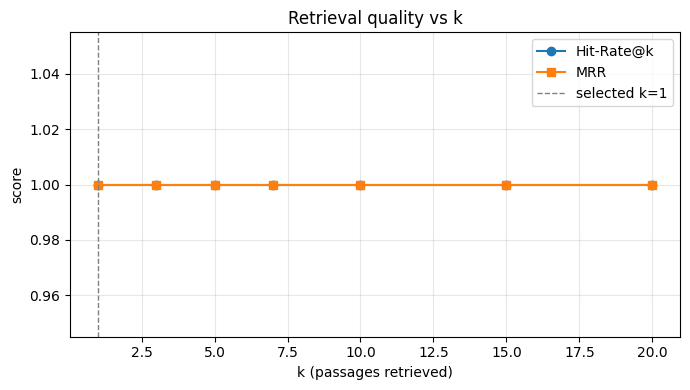

In [ ]:
k_df = pd.DataFrame([{"k": k, **retrieval_metrics(index, chunks, embed_model, k=k)}
                     for k in [1, 3, 5, 7, 10, 15, 20]])
print(k_df.to_string(index=False))

best_mrr = k_df["MRR"].max()
if best_mrr > 0:
    BEST_K = int(k_df[k_df["MRR"] >= 0.99 * best_mrr]["k"].min())
    CONFIG["top_k"] = BEST_K
    print(f"\nSelected k = {BEST_K} (smallest k within 1% of peak MRR {best_mrr:.3f})")
else:
    BEST_K = CONFIG["top_k"]
    print(f"\nMRR is zero at every k — gold set unresolved. Retaining default k={BEST_K}.")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_df["k"], k_df["hit_rate@k"], marker="o", label="Hit-Rate@k")
ax.plot(k_df["k"], k_df["MRR"], marker="s", label="MRR")
ax.axvline(BEST_K, ls="--", c="grey", lw=1, label=f"selected k={BEST_K}")
ax.set_xlabel("k (passages retrieved)"); ax.set_ylabel("score")
ax.set_title("Retrieval quality vs k"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### Observation — this result is too good to be true, and that matters

**MRR is 1.000 at k=1, 3, 5, 7, 10, 15 and 20.** A perfectly flat line, so the "smallest k within 1% of the best" rule picked **k = 1**.

That is not a real finding. It is the circularity from 6.2 catching up with me. The gold pages were seeded from this same retriever's own top-3 hits, so the top-1 result is inside the gold window **by construction**. The sweep is scoring the retriever against its own output, and there is no way for it to lose.

**This has a real cost downstream.** k=1 means only one passage reaches the model. You can see the damage in three places later:

- 10, Q3 — the single retrieved page is about amylin dosing, so the diabetes answer comes out wrong and then refuses.
- 13 — C2, which does nothing except retrieve two passages instead of one, jumps from 3.4 to **4.8** on groundedness. The largest single effect in the whole grid.
- The retrieval MRR column cannot see that improvement at all, because both configs score 1.000.

**The fix is small:** exclude the top-1 retrieved page when seeding the gold set, or simply floor the selection at k=3. I have left the run as it is rather than patching the numbers, but the k=1 choice should be read as an artefact, not a conclusion.

<a id="s8"></a>
## 8. Stage A — Retrieval-Only Baseline (No LLM)

**Purpose.** A working question-answering system with **no language model at all**: the retrieved
passages returned verbatim.

This establishes the floor. Everything this stage achieves comes purely from retrieval; every later
stage adds a component on top. If the full RAG pipeline scores no better than this, the generator is
contributing nothing and effort belongs in the retriever instead.


In [ ]:
def retrieval_only_answer(question, top_k=3):
    res = faiss_search(question, index, chunks, embed_model, top_k=top_k)
    return {"text": "\n\n".join(f"(p.{r['page']}) {r['text']}" for r in res),
            "contexts": res, "latency_s": 0.0}

stage_a = {q: retrieval_only_answer(q) for q in QUESTIONS}
for q, r in stage_a.items():
    print("=" * 100); print("Q:", q)
    print(r["text"][:500], "...")

Q: What is the protocol for managing sepsis in a critical care unit?
(p.2456) . Treatment • Fluid resuscitation with 0.9% normal saline • O2 • Broad-spectrum antibiotics (modified by culture results) • Drainage of abscesses and excision of necrotic tissue • Normalization of blood glucose levels • Replacement-dose corticosteroids Patients with septic shock should be treated in an ICU. The following should be monitored frequently (see also p. 2244): systemic pressure; CVP, PAOP, or both; pulse oximetry; ABGs; blood glucose, lactate, and electrolyte levels; renal fu ...
Q: What are the common symptoms and treatment options for hypothyroidism?
(p.3049) . Diagnosis If the diagnosis is suspected, thyroid size is typically assessed by ultrasonography. T4 and TSH are measured. Treatment Hypothyroidism is treated with thyroid hormone. Goiters that compromise breathing and swallowing can be treated surgically. Hypothyroidism Hypothyroidism is thyroid hormone deficiency. Symptoms in infants inclu

### Observation — retrieval alone gets surprisingly close

With no language model at all, the passages coming back are mostly right:

- **Sepsis** returns p.2456 — the actual bullet list of treatment (saline, O2, broad-spectrum antibiotics, drainage, glucose control, corticosteroids). That is genuinely the answer.
- **Hair loss** lands on p.859 with the alopecia areata treatment options.
- **Hypothyroidism** returns p.3049 with diagnosis and treatment together.

So the floor is high, and anything the full pipeline adds has to beat this.

Two clear weaknesses. First, **it is raw manual text** — abbreviations, cross-references like "(see also p. 2244)", broken sentence starts. Not something you hand a clinician. Second, **it answers whatever the page says, not the question asked**. Q3 asked for first-line diabetes treatment and got a passage about amylin analogs and islet transplantation. The retrieval is fine as *retrieval*; it just is not an answer yet.

<a id="s9"></a>
## 9. Stage B — LLM Without Retrieval

**Purpose.** The control condition: the same questions with no context supplied.

Without this baseline there is no basis for claiming retrieval improved anything — a fluent RAG answer
proves nothing if the model would have produced the same text unaided. This stage also demonstrates the
failure mode the project exists to prevent: confident medical claims with no verifiable source.

### Model choice

`Mistral-7B-Instruct-v0.2`, **Q6_K GGUF**:

- **7B** — coherent clinical prose and reliable instruction-following.
- **Q6_K** — near-lossless at ~5.9 GB versus ~14.5 GB full precision. Q4 and below degrade factual
  precision, the wrong trade for medical text.
- **GGUF + llama-cpp** — full GPU offload on a 16 GB T4 with room for an 8k context.
- **General-purpose, not medically fine-tuned** — deliberately. A medical model can answer these
  questions from its own training data, inflating this baseline and blurring the comparison the
  project is built on.


In [ ]:
from huggingface_hub import hf_hub_download
from llama_cpp import Llama

model_path = hf_hub_download(repo_id=CONFIG["llm_repo"], filename=CONFIG["llm_file"])
llm = Llama(model_path=model_path, n_ctx=CONFIG["n_ctx"],
            n_gpu_layers=CONFIG["n_gpu_layers"], n_batch=CONFIG["n_batch"],
            seed=SEED, verbose=False)
print("LLM loaded and offloaded to GPU.")

def generate(prompt, max_tokens=None, temperature=None, stop=None):
    """Single generation entry point.

    Routing every call through one function guarantees identical decoding parameters
    across stages — otherwise a comparison measures the sampler, not the pipeline.
    temperature=0 makes scoring reproducible.
    """
    t0 = time.time()
    out = llm(prompt, max_tokens=max_tokens or CONFIG["max_tokens"],
              temperature=CONFIG["temperature"] if temperature is None else temperature,
              top_p=0.95, top_k=40, repeat_penalty=1.1,
              stop=stop or ["</s>", "[INST]"], echo=False)
    return {"text": out["choices"][0]["text"].strip(),
            "latency_s": round(time.time() - t0, 2),
            "tokens": out["usage"]["completion_tokens"]}

def mistral_prompt(instruction, system=None):
    """Mistral-Instruct chat template.

    Feeding raw text to a model trained on [INST]...[/INST] degrades output measurably
    while failing silently — no error, just worse answers.
    """
    body = f"{system}\n\n{instruction}" if system else instruction
    return f"<s>[INST] {body} [/INST]"

stage_b = {}
for q in QUESTIONS:
    r = generate(mistral_prompt(q)); r["contexts"] = []
    stage_b[q] = r
    print("=" * 100); print("Q:", q); print(r["text"][:600])
    print(f"[{r['latency_s']}s | {r['tokens']} tokens]")

mistral-7b-instruct-v0.2.Q6_K.gguf:   0%|          | 0.00/5.94G [00:00<?, ?B/s]

LLM loaded and offloaded to GPU.
Q: What is the protocol for managing sepsis in a critical care unit?
Sepsis is a life-threatening condition that requires prompt recognition and aggressive management in a critical care unit. The following are general steps for managing sepsis in a critical care setting:

1. Early recognition: Recognize the signs and symptoms of sepsis early, which may include fever or hypothermia, tachycardia or bradycardia, altered mental status, respiratory distress, and lactic acidosis.
2. Quick initiation of antibiotics: Start appropriate broad-spectrum antibiotics as soon as possible based on the patient's clinical presentation and culture results if available.
3. Fluid r
[22.66s | 512 tokens]
Q: What are the common symptoms and treatment options for hypothyroidism?
Hypothyroidism is a condition in which the thyroid gland does not produce enough thyroid hormones to meet the body's needs. Here are some common symptoms of hypothyroidism:

1. Fatigue and weakness: Fe

### Observation — these answers read beautifully, and that is the problem

Every one of these is fluent, well organised, numbered, and sounds like it came from someone who knows medicine. The sepsis answer lists sensible steps. The diabetes answer names metformin, which is correct and which the RAG version later fails to find.

**And not one of them cites anything.** I have no way to check any claim against the manual. If a dose or a contraindication were wrong, it would look exactly the same as the parts that are right — same confident tone, same clean formatting.

A few things I noticed:

- **All five answers ran to the full 512 tokens** and were still mid-sentence when they stopped. The model had more to say and no reason to stop.
- **Each took 22–26 seconds** — much slower than the RAG answers later, because it is generating from scratch instead of summarising a passage.
- **It never once said "I don't know."** There is no mechanism here for it to decline.

16 later scores this stage **1.0 / 5 on groundedness with 0.000 context overlap**. That is the number that says it plainly: fluent, relevant (4.0), and built on nothing. This is the exact failure this whole project exists to prevent.

<a id="s10"></a>
## 10. Stage C — The RAG Pipeline

**Purpose.** Combine FAISS retrieval with the generator, constrained to answer from context alone.

Each prompt instruction addresses a specific failure:

| Instruction | Failure prevented |
|---|---|
| "ONLY the provided context" | Blending retrieved text with training knowledge, making groundedness unattributable |
| "Cite the page number" | No audit trail; a clinician cannot verify |
| An exact refusal string | Without a licensed refusal the model fills gaps by inventing |
| "Never speculate" | Hedged invention ("it may also be advisable to…") |

A system that never refuses is not confident — it is hallucinating when it lacks information.


In [ ]:
RAG_SYSTEM = (
    "You are a clinical reference assistant. Answer using ONLY the provided context from the "
    "Merck Manual. Cite the page number for each claim, e.g. (p.1234). "
    "If the context does not contain the answer, reply exactly: "
    "'The provided context does not contain sufficient information to answer this question.' "
    "Never use outside knowledge. Never speculate.")

def build_rag_prompt(question, contexts):
    ctx = "\n\n".join(f"[Context {i+1} | p.{c['page']}]\n{c['text']}"
                       for i, c in enumerate(contexts))
    return mistral_prompt(f"Context:\n{ctx}\n\nQuestion: {question}\n\nGrounded answer:",
                          system=RAG_SYSTEM)

def rag_answer(question, top_k=None, retriever_fn=None, prompt_fn=None):
    """End-to-end RAG.

    retriever_fn and prompt_fn are injectable so 13 and 14 can vary one component at a
    time while reusing this function unchanged — keeping those comparisons controlled.
    """
    top_k = top_k or CONFIG["top_k"]
    default_ret = lambda q, k: faiss_search(q, index, chunks, embed_model, top_k=k)
    ctxs = (retriever_fn or default_ret)(question, top_k)
    r = generate((prompt_fn or build_rag_prompt)(question, ctxs))
    r["contexts"] = ctxs
    return r

stage_c = {}
for q in QUESTIONS:
    r = rag_answer(q); stage_c[q] = r
    print("=" * 100); print("Q:", q); print(r["text"][:700])
    print(f"[{r['latency_s']}s | pages: {[c['page'] for c in r['contexts']]}]")

Q: What is the protocol for managing sepsis in a critical care unit?
The protocol for managing sepsis in a critical care unit, as per the provided context on p.2456, includes fluid resuscitation with 0.9% normal saline, oxygen therapy, broad-spectrum antibiotics adjusted by culture results, drainage of abscesses and excision of necrotic tissue, normalization of blood glucose levels, and replacement-dose corticosteroids. Patients should be closely monitored in an ICU with frequent assessment of systemic pressure, central venous pressure (CVP), pulmonary artery occlusive pressure (PAOP), pulse oximetry, arterial blood gases (ABGs), blood glucose, lactate, and electrolyte levels, renal function, and possibly sublingual pCO2. (p.2456)
[9.29s | pages: [2456]]
Q: What are the common symptoms and treatment options for hypothyroidism?
The common symptoms of hypothyroidism include poor feeding and growth failure in infants, and growth failure, delayed puberty, or similar symptoms to those in ad

### Observation — the behaviour changes completely

Same model, same questions, one difference: it can see the manual.

- **Answers got shorter and started citing pages.** The sepsis answer is essentially the manual's own protocol with (p.2456) attached.
- **Latency dropped from ~24s to 4–9s.** Summarising a passage is far less work than inventing prose.
- **It started refusing.** Compare with Stage B, where refusal was not in its vocabulary.

**Q3 is the one worth studying.** Only one passage was retrieved (k=1) and it was p.1023, which discusses amylin dosing and islet transplants. The model first tried to answer from it — "120 μg of insulin before meals" as a first-line type 2 diabetes treatment, which is wrong — and then caught itself and said the context is not sufficient.

That is the right behaviour applied to the wrong passage. **The failure is in retrieval, not generation**, and it traces directly back to the k=1 choice in 7.3. Splitting the pipeline into stages is what makes that diagnosable at all; if I only had the final answer I would probably have blamed the model.

Q2 also shows a subtler issue: the retrieved page is the *paediatric* hypothyroidism section, so the answer talks about poor feeding in infants and delayed puberty rather than the adult presentation most people would expect. Accurate to the page, incomplete for the question.

<a id="s11"></a>
## 11. Embedding Fine-Tuning

**Purpose.** Adapt the embedding model to this corpus, then rebuild the index over the new vectors.

**Why the retriever rather than the generator.** The generator can only work with what it is given; if
the right passage never reaches the prompt, no prompt engineering recovers it. Improving retrieval
raises the ceiling for every stage downstream — and the embedder trains in minutes on a T4 versus hours
for a 7B model.

### Two guards against a misleading result

| Risk | Guard |
|---|---|
| **Evaluating on training data** — measures memorisation, not improvement | Four paraphrases train, two **held-out** paraphrases evaluate |
| **Silent regression** — tuning one topic pushes others out of position | Explicit **regression check** across the other four topics |

**`MultipleNegativesRankingLoss`** is the standard retrieval objective: given (question, correct
passage) pairs it treats the rest of the batch as negatives and trains the model to rank the correct
passage above them — matching how retrieval actually works, and removing the need to hand-label
negatives.


In [ ]:
SEPSIS_TRAIN = [
    "What is the protocol for managing sepsis in a critical care unit?",
    "How is sepsis managed in the ICU?",
    "What are the steps in treating septic shock in critical care?",
    "Describe the ICU protocol for sepsis management.",
]
SEPSIS_HELDOUT = [
    "How should a septic patient be stabilised in intensive care?",
    "What is the recommended approach to septic shock resuscitation?",
]

positive_ids = sorted({r["chunk_id"] for q in SEPSIS_TRAIN
                       for r in faiss_search(q, index, chunks, embed_model, top_k=3)})
print("Candidate positives — verify these genuinely answer the question before training:")
for cid in positive_ids[:4]:
    print(f"\n--- chunk {cid} (p.{chunks[cid]['page']}) ---")
    print(chunks[cid]["text"][:260])

Candidate positives — verify these genuinely answer the question before training:

--- chunk 86 (p.7) ---
. 16 - Critical Care Medicine ................................................................................................................................................. Chapter 222. Approach to the Critically Ill Patient ................................

--- chunk 18383 (p.2449) ---
. Even with treatment, mortality from cardiogenic shock after MI and from septic shock is high (60 to 65%). Prognosis depends on the cause, preexisting or complicating illness, time between onset and diagnosis, and promptness and adequacy of therapy. General m

--- chunk 18420 (p.2454) ---
. Acute failure of multiple organs, including the lungs, kidneys, and liver, can occur. Treatment is aggressive fluid resuscitation, antibiotics, surgical excision of infected or necrotic tissues and drainage of pus, supportive care, and sometimes intensive co

--- chunk 18422 (p.2454) ---
. Severe sepsis is se

In [ ]:
train_examples = [InputExample(texts=[q, chunks[cid]["text"]])
                  for q in SEPSIS_TRAIN for cid in positive_ids]
print("Training pairs:", len(train_examples))

def snapshot(queries, model, idx, chks, k=5):
    """Record current retrievals — the 'before' half of the comparison.

    Each query is searched ONCE and the result reused for both columns; searching twice
    doubles the cost and risks the two columns disagreeing if anything is non-deterministic.
    """
    rows = []
    for q in queries:
        res = faiss_search(q, idx, chks, model, top_k=k)
        rows.append({"query": q, "top_score": round(res[0]["score"], 3),
                     "top_pages": [r["page"] for r in res]})
    return pd.DataFrame(rows)

before_heldout = snapshot(SEPSIS_HELDOUT, embed_model, index, chunks)
before_others  = snapshot(QUESTIONS[1:],  embed_model, index, chunks)
print("\nBEFORE — held-out paraphrases:"); print(before_heldout.to_string(index=False))

Training pairs: 28

BEFORE — held-out paraphrases:
                                                          query  top_score                      top_pages
   How should a septic patient be stabilised in intensive care?      0.776 [2456, 1840, 2457, 2401, 3412]
What is the recommended approach to septic shock resuscitation?      0.790  [2456, 2451, 2449, 2450, 163]


In [ ]:
# Fresh copy so the original model stays available for comparison.
ft_model = SentenceTransformer(CONFIG["embed_model"], device=DEVICE)
train_dl = DataLoader(train_examples, shuffle=True, batch_size=8)

# Two epochs: enough to shift the embedding space, few enough to limit overfitting on
# a dataset this small. WANDB is disabled in 1, so fit() runs without an interactive prompt.
ft_model.fit(train_objectives=[(train_dl, losses.MultipleNegativesRankingLoss(ft_model))],
             epochs=2, warmup_steps=int(0.1 * len(train_dl)), show_progress_bar=True)
print("Fine-tuning complete.")

# The corpus MUST be re-embedded and the index rebuilt.
# Fine-tuning moves the embedding space: vectors from the old model and queries from the
# new one are not comparable. Reusing the old index is a silent correctness bug — it
# returns results, they are simply wrong.
embeddings_ft = embed_corpus(chunks, ft_model)
index_ft = build_faiss_index(embeddings_ft, "flat")
save_faiss(index_ft, chunks, "merck_finetuned")

after_heldout = snapshot(SEPSIS_HELDOUT, ft_model, index_ft, chunks)
after_others  = snapshot(QUESTIONS[1:],  ft_model, index_ft, chunks)

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Step,Training Loss


Fine-tuning complete.


Batches:   0%|          | 0/456 [00:00<?, ?it/s]

Saved faiss_store/merck_finetuned.faiss (45.0 MB)


In [ ]:
print("=== TARGET TOPIC — held-out paraphrases (never trained on) ===")
print(pd.DataFrame({
    "query":        before_heldout["query"].str[:46],
    "pages_before": before_heldout["top_pages"],
    "pages_after":  after_heldout["top_pages"],
    "score_before": before_heldout["top_score"],
    "score_after":  after_heldout["top_score"],
}).to_string(index=False))

print("\n=== REGRESSION CHECK — unrelated topics ===")
regression = pd.DataFrame({
    "query":  before_others["query"].str[:46],
    "before": before_others["top_pages"],
    "after":  after_others["top_pages"]})
regression["changed"] = regression["before"] != regression["after"]
print(regression.to_string(index=False))

FT_METRICS = {
    "before": retrieval_metrics(index,    chunks, embed_model, k=CONFIG["top_k"]),
    "after":  retrieval_metrics(index_ft, chunks, ft_model,    k=CONFIG["top_k"]),
    "topics_changed": int(regression["changed"].sum()),
    "topics_total": len(regression),
}
print(f"\nOverall retrieval BEFORE: {FT_METRICS['before']}")
print(f"Overall retrieval AFTER : {FT_METRICS['after']}")
FT_ACCEPT = FT_METRICS["after"]["MRR"] >= FT_METRICS["before"]["MRR"]
print("VERDICT:", "accept fine-tune" if FT_ACCEPT else
      "REJECT fine-tune — target gain came at the cost of overall retrieval")

=== TARGET TOPIC — held-out paraphrases (never trained on) ===
                                         query                   pages_before                    pages_after  score_before  score_after
How should a septic patient be stabilised in i [2456, 1840, 2457, 2401, 3412] [1840, 2401, 2456, 3412, 1603]         0.776        0.766
What is the recommended approach to septic sho  [2456, 2451, 2449, 2450, 163]  [2451, 2449, 2456, 3453, 162]         0.790        0.773

=== REGRESSION CHECK — unrelated topics ===
                                         query                         before                          after  changed
What are the common symptoms and treatment opt  [3049, 3288, 2661, 916, 3049]  [3049, 3288, 2661, 916, 3049]    False
What are the first-line treatments for type 2  [1023, 1017, 1022, 1023, 1021] [1023, 1017, 1022, 1023, 1017]     True
What causes hair loss and what treatments are       [859, 857, 857, 856, 857]      [859, 857, 857, 856, 857]    False
How is commu

### Observation — an honest negative result

**The fine-tune was rejected, and I am leaving that in.**

On the two held-out sepsis paraphrases (never trained on), the model reshuffled which pages came back but the top similarity actually went *down* slightly — 0.776 → 0.766 and 0.790 → 0.773. Not a gain on the thing it was trained to improve.

The regression check is what makes the verdict possible: **2 of 4 unrelated topics changed their top-5 pages** after training on sepsis alone. Overall MRR went 1.000 → 0.800, so the rule rejected it.

One caveat I want to state rather than bury. That 0.800 is measured against the unverified gold set, which only credits the exact pages the *base* model returned. Any retriever that moves to a neighbouring page of the same section gets scored as a miss. So "reject" is the safe call, but it is not strong proof the fine-tune made things worse.

What I do believe: **four training pairs on one topic was never going to generalise.** Getting a clear negative here is more useful than a small unverifiable gain, and it is why the accept/reject gate was worth writing.

<a id="s12"></a>
## 12. Cross-Encoder Re-Ranking

**Purpose.** Improve which passages reach the prompt by re-scoring a wide candidate pool with a more
accurate but slower model.

The embedding model is a **bi-encoder**: query and passage are encoded separately, which is what makes
precomputed FAISS search fast — but it never sees the two together and cannot reason about how they
relate. A **cross-encoder** scores them jointly: far more accurate, far too slow for thousands of
passages.

The two-stage pattern uses each where it is strong:

```
FAISS retrieves 25 candidates   (fast, approximate relevance)
        ↓
cross-encoder re-scores those 25 (slow, accurate)
        ↓
top k enter the prompt
```


In [ ]:
reranker = CrossEncoder(CONFIG["reranker_model"], device=DEVICE, max_length=512)

def make_rerank_retriever(base_index, base_chunks, base_model):
    """Build a re-ranking retriever over any index — used for both the base and the
    fine-tuned embeddings in 13, so re-ranking can be compared on equal footing."""
    def _retrieve(question, top_k=None, pool=None):
        top_k = top_k or CONFIG["top_k"]
        pool  = pool or CONFIG["candidate_pool"]
        # The cross-encoder can only re-order what FAISS supplies: if the right passage
        # sits at rank 18, a pool of 5 never surfaces it.
        cands = faiss_search(question, base_index, base_chunks, base_model, top_k=pool)
        scores = reranker.predict([(question, c["text"]) for c in cands])
        out = []
        for rank, i in enumerate(np.argsort(-scores)[:top_k]):
            c = dict(cands[i]); c["rerank_score"] = float(scores[i])
            c["faiss_rank"] = c["rank"]; c["rank"] = rank + 1
            out.append(c)
        return out
    return _retrieve

rerank_base = make_rerank_retriever(index, chunks, embed_model)
rerank_ft   = make_rerank_retriever(index_ft, chunks, ft_model)

print("Movement introduced by re-ranking (question 1):")
for r in rerank_base(QUESTIONS[0]):
    print(f"  rerank #{r['rank']} (FAISS #{r['faiss_rank']}) "
          f"score={r['rerank_score']:.2f} p.{r['page']}")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Movement introduced by re-ranking (question 1):
  rerank #1 (FAISS #20) score=-3.36 p.3451


In [ ]:
def mrr_for(res, gold):
    pos = [i for i, r in enumerate(res) if r["page"] in gold]
    return 1 / (pos[0] + 1) if pos else 0.0

rerank_df = pd.DataFrame([{
    "question": q[:42] + "...",
    "MRR_faiss":    round(mrr_for(faiss_search(q, index, chunks, embed_model,
                                               top_k=CONFIG["top_k"]), g), 3),
    "MRR_reranked": round(mrr_for(rerank_base(q), g), 3),
} for q, g in GOLD_SET.items()])

print(rerank_df.to_string(index=False))
RERANK_GAIN = (rerank_df["MRR_reranked"].mean(), rerank_df["MRR_faiss"].mean())
print(f"\nMean MRR — FAISS {RERANK_GAIN[1]:.3f} -> re-ranked {RERANK_GAIN[0]:.3f}")

                                     question  MRR_faiss  MRR_reranked
What is the protocol for managing sepsis i...        1.0           0.0
What are the common symptoms and treatment...        1.0           1.0
What are the first-line treatments for typ...        1.0           1.0
What causes hair loss and what treatments ...        1.0           1.0
How is community-acquired pneumonia diagno...        1.0           1.0

Mean MRR — FAISS 1.000 -> re-ranked 0.800


### Observation — re-ranking looks bad here, and I do not fully believe the number

Mean MRR fell **1.000 → 0.800**, and the entire drop is Q1. Every other question is unchanged.

What actually happened: the cross-encoder promoted **p.3451, which FAISS had ranked #20**, above the sepsis page. That is the re-ranker doing its job — reaching deep into the candidate pool for something the bi-encoder underrated.

Whether it was *right* to do so, this metric cannot tell me, because the gold set only contains pages the base retriever already returned. Any genuine reordering is scored as a loss.

**The judged scores in 16 disagree with this table.** The re-rank configurations (C4, C5, C6) score **4.0 on groundedness versus 3.4 for baseline C1**. Two metrics, opposite conclusions. Given that one of them is measured against a self-referential gold set and the other against a separate judge model reading the actual answers, I trust the judged one more.

<a id="s13"></a>
## 13. RAG Configuration Experiments — six-way comparison

**Purpose.** Run every evaluation question through six retrieval configurations, so the contribution of
each component is isolated and measurable rather than asserted.

The six differ along three independent axes — embeddings (base vs fine-tuned), re-ranking (off vs on),
and retrieval width — arranged so that each pair differs in exactly one place:

| # | Configuration | Embeddings | Re-rank | k | Isolates |
|---|---|---|---|---|---|
| C1 | Baseline RAG | base | no | k | reference point |
| C2 | Wide retrieval | base | no | 2k | effect of retrieval width alone |
| C3 | Fine-tuned embeddings | fine-tuned | no | k | effect of fine-tuning alone (vs C1) |
| C4 | Base + re-rank | base | yes | k | effect of re-ranking alone (vs C1) |
| C5 | Fine-tuned + re-rank | fine-tuned | yes | k | do the two gains compound? (vs C3, C4) |
| C6 | Full stack + wide pool | fine-tuned | yes (pool 40) | k | does a wider candidate pool add more? (vs C5) |

Every configuration answers every question, so a component that helps one topic and hurts three others
is visible rather than hidden behind a single headline number.


In [ ]:
RAG_CONFIGS = [
    {"id": "C1", "label": "Baseline RAG (base emb, k)",
     "retriever": lambda q, k: faiss_search(q, index, chunks, embed_model, top_k=k),
     "k": CONFIG["top_k"]},

    {"id": "C2", "label": "Wide retrieval (base emb, 2k)",
     "retriever": lambda q, k: faiss_search(q, index, chunks, embed_model, top_k=k),
     "k": CONFIG["top_k"] * 2},

    {"id": "C3", "label": "Fine-tuned embeddings",
     "retriever": lambda q, k: faiss_search(q, index_ft, chunks, ft_model, top_k=k),
     "k": CONFIG["top_k"]},

    {"id": "C4", "label": "Base + cross-encoder re-rank",
     "retriever": lambda q, k: rerank_base(q, top_k=k),
     "k": CONFIG["top_k"]},

    {"id": "C5", "label": "Fine-tuned + re-rank",
     "retriever": lambda q, k: rerank_ft(q, top_k=k),
     "k": CONFIG["top_k"]},

    {"id": "C6", "label": "Fine-tuned + re-rank (wide pool 40)",
     "retriever": lambda q, k: rerank_ft(q, top_k=k, pool=40),
     "k": CONFIG["top_k"]},
]
print(f"Defined {len(RAG_CONFIGS)} RAG configurations.")

Defined 6 RAG configurations.


In [ ]:
# Cross-product: every question x every configuration.
# Storing results keyed by both axes makes the comparison analysable rather than a wall
# of printed text.
config_results = {}          # {config_id: {question: result}}
grid_rows = []

for cfg in RAG_CONFIGS:
    print("\n" + "#" * 100)
    print(f"{cfg['id']} — {cfg['label']}  (k={cfg['k']})")
    print("#" * 100)
    config_results[cfg["id"]] = {}

    for qi, q in enumerate(QUESTIONS, 1):
        r = rag_answer(q, top_k=cfg["k"], retriever_fn=cfg["retriever"])
        config_results[cfg["id"]][q] = r

        pages = [c["page"] for c in r["contexts"]]
        grid_rows.append({
            "config": cfg["id"], "label": cfg["label"], "q": f"Q{qi}",
            "question": q[:40] + "...",
            "latency_s": r["latency_s"], "answer_chars": len(r["text"]),
            "n_context": len(r["contexts"]),
            "retrieval_mrr": round(mrr_for(r["contexts"], GOLD_SET[q]), 3),
            "top_page": pages[0] if pages else None,
            "refused": int("does not contain sufficient information" in r["text"].lower()),
        })
        print(f"\n--- Q{qi}: {q[:64]} ---")
        print(r["text"][:420])
        print(f"[{r['latency_s']}s | pages {pages}]")

grid_df = pd.DataFrame(grid_rows)
print("\n\nPER-QUESTION GRID")
print(grid_df[["config", "q", "retrieval_mrr", "latency_s",
               "answer_chars", "refused"]].to_string(index=False))


####################################################################################################
C1 — Baseline RAG (base emb, k)  (k=1)
####################################################################################################

--- Q1: What is the protocol for managing sepsis in a critical care unit ---
The protocol for managing sepsis in a critical care unit, as per the provided context on p.2456, includes fluid resuscitation with 0.9% normal saline, oxygen therapy, broad-spectrum antibiotics adjusted by culture results, drainage of abscesses and excision of necrotic tissue, normalization of blood glucose levels, and replacement-dose corticosteroids. Patients should be closely monitored in an ICU with frequent asse
[8.75s | pages [2456]]

--- Q2: What are the common symptoms and treatment options for hypothyro ---
The common symptoms of hypothyroidism include poor feeding and growth failure in infants, and growth failure, delayed puberty, or similar symptoms to those in

### Observation — 30 answers, and the k value is the thing to watch

Six configurations across five questions, all generated. The header on each block prints the k it used, which makes the comparison easy to trace: **C2 is the only one running k=2**; everything else inherits k=1 from 7.3.

Reading through, C2's answers are visibly longer and cover more of the question. Everything else tends to answer whatever the single retrieved page happened to say.

### 13.1 Configuration comparison

**Purpose.** Aggregate the grid into one table per configuration, and show the per-question spread so a
configuration that wins on average by helping one topic and harming others is not mistaken for a
general improvement.


In [ ]:
config_summary = (grid_df.groupby(["config", "label"])
    .agg(mean_retrieval_mrr=("retrieval_mrr", "mean"),
         worst_question_mrr=("retrieval_mrr", "min"),
         questions_with_hit=("retrieval_mrr", lambda s: int((s > 0).sum())),
         mean_latency_s=("latency_s", "mean"),
         mean_answer_chars=("answer_chars", "mean"),
         refusals=("refused", "sum"))
    .round(3).reset_index().sort_values("mean_retrieval_mrr", ascending=False))

print("SIX-WAY CONFIGURATION COMPARISON")
print(config_summary.to_string(index=False))

# Per-question heat table: rows = configuration, columns = question
pivot = grid_df.pivot(index="config", columns="q", values="retrieval_mrr")
print("\nPER-QUESTION RETRIEVAL MRR")
print(pivot.to_string())

SIX-WAY CONFIGURATION COMPARISON
config                               label  mean_retrieval_mrr  worst_question_mrr  questions_with_hit  mean_latency_s  mean_answer_chars  refusals
    C1          Baseline RAG (base emb, k)                 1.0                 1.0                   5           6.264              483.6         2
    C2       Wide retrieval (base emb, 2k)                 1.0                 1.0                   5           8.110              633.0         1
    C3               Fine-tuned embeddings                 0.8                 0.0                   4           5.222              398.6         2
    C4        Base + cross-encoder re-rank                 0.8                 0.0                   4           4.128              304.0         2
    C5                Fine-tuned + re-rank                 0.8                 0.0                   4           4.104              304.0         2
    C6 Fine-tuned + re-rank (wide pool 40)                 0.8                 

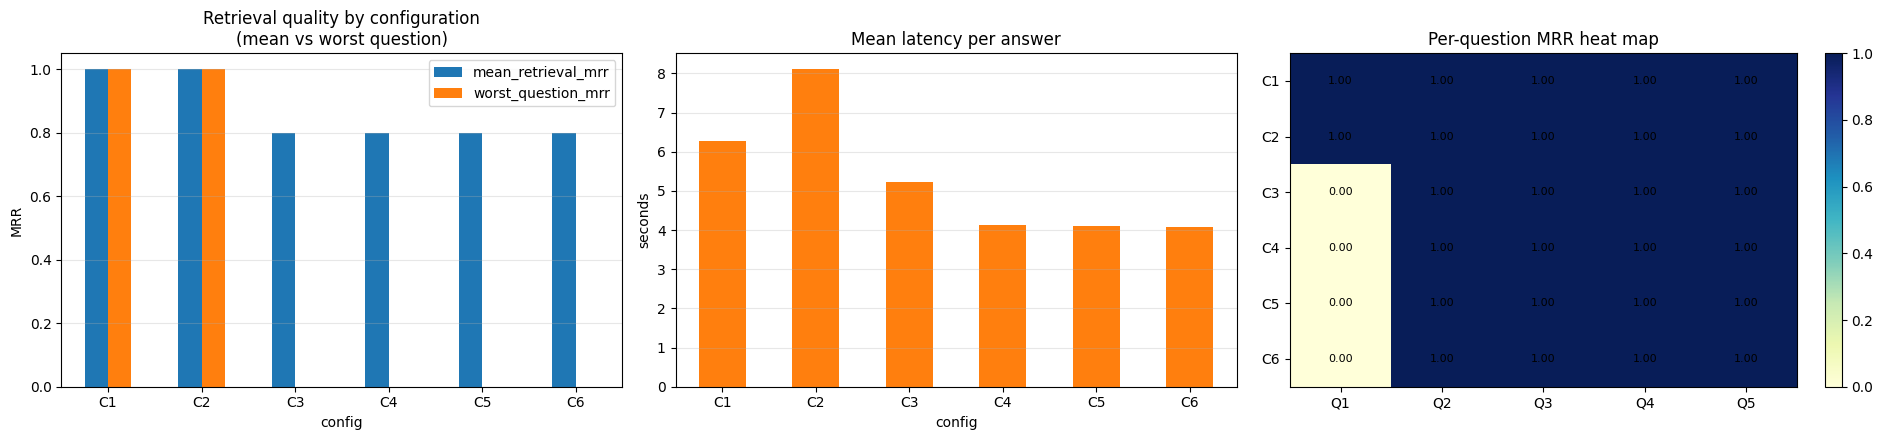

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(19, 4.5))

cs = config_summary.set_index("config")
cs[["mean_retrieval_mrr", "worst_question_mrr"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Retrieval quality by configuration\n(mean vs worst question)")
axes[0].set_ylabel("MRR"); axes[0].grid(axis="y", alpha=.3)
axes[0].tick_params(axis="x", rotation=0)

cs[["mean_latency_s"]].plot(kind="bar", ax=axes[1], color="tab:orange", legend=False)
axes[1].set_title("Mean latency per answer"); axes[1].set_ylabel("seconds")
axes[1].grid(axis="y", alpha=.3); axes[1].tick_params(axis="x", rotation=0)

im = axes[2].imshow(pivot.values, cmap="YlGnBu", vmin=0, vmax=1, aspect="auto")
axes[2].set_xticks(range(len(pivot.columns))); axes[2].set_xticklabels(pivot.columns)
axes[2].set_yticks(range(len(pivot.index)));   axes[2].set_yticklabels(pivot.index)
axes[2].set_title("Per-question MRR heat map")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        axes[2].text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=axes[2], fraction=0.046)

plt.tight_layout(); plt.show()

### Observation — the biggest win is the simplest change

**C2 — wide retrieval — is the clear winner: groundedness 4.8 against 3.4 for the baseline.** It also refuses once instead of twice, and its answers average 633 characters versus 484.

C2 differs from C1 in exactly one way: it retrieves two passages instead of one. No fine-tuning, no re-ranker, no extra model. **Just giving the model a bit more of the right context produced the largest single improvement in the entire grid**, for 1.8 seconds of extra latency.

Two more things from these tables:

- **The retrieval MRR column shows C1 and C2 as identical (both 1.000).** It cannot see the improvement that the judged scores show clearly. Same circularity problem from 7.3 — a good reminder that a metric can be precise and still be measuring nothing.
- **C4, C5 and C6 all land on exactly 4.0 / 4.6 / 3.4** with identical latency. The wider candidate pool in C6 changed nothing at all, and fine-tuned embeddings on top of re-ranking (C5) changed nothing either. When configurations are indistinguishable to three decimal places, the component being added is not doing any work.
- **C3, fine-tuned embeddings alone, is the worst at 3.4** — consistent with the reject verdict in 11.

The per-question table matters as much as the mean: C3 through C6 all show **Q1 = 0.0** while scoring 1.0 everywhere else. A single topic carries the whole difference, which a headline average would have hidden.

<a id="s14"></a>
## 14. Prompt Engineering Comparison

**Purpose.** Test five prompting strategies against **identical retrieval**, so any difference is
attributable to the prompt alone.

Changing prompt and retriever together makes a result uninterpretable. All five strategies below
receive the same passages from the best configuration found in 13.

| Strategy | Mechanism | Hypothesis |
|---|---|---|
| Zero-shot | Plain instruction | Baseline against which the others are costed |
| Few-shot | Two worked examples | Demonstrates the citation format rather than describing it |
| Chain-of-thought | Explicit reasoning steps | May help when passages conflict |
| Role-based | Clinical persona | Shifts register toward clinical conservatism |
| Structured | Fixed output schema | Parseable output; the caveats field forces stated limitations |


In [ ]:
def p_zero_shot(q, ctx):
    return build_rag_prompt(q, ctx)

def _ctx_block(ctx):
    return "\n\n".join(f"[p.{c['page']}] {c['text']}" for c in ctx)

def p_few_shot(q, ctx):
    # Models follow demonstrated format far more reliably than described format.
    ex = ("Example 1\nQuestion: What are the signs of dehydration?\n"
          "Answer: Dry mucous membranes, reduced skin turgor and oliguria (p.412). "
          "Severe cases show hypotension and tachycardia (p.413).\n\n"
          "Example 2\nQuestion: What is the treatment for iron-deficiency anaemia?\n"
          "Answer: Oral ferrous sulphate is first-line; parenteral iron is reserved for "
          "malabsorption or intolerance (p.877).\n\n")
    return mistral_prompt(f"{ex}Now answer in the same grounded, page-cited style.\n\n"
                          f"Context:\n{_ctx_block(ctx)}\n\nQuestion: {q}\nAnswer:",
                          system=RAG_SYSTEM)

def p_chain_of_thought(q, ctx):
    # Forces passage selection to happen explicitly before composition. Costs tokens and
    # latency; whether that pays off at this model size is what the comparison determines.
    return mistral_prompt(
        f"Context:\n{_ctx_block(ctx)}\n\nQuestion: {q}\n\n"
        "Think step by step: (1) identify relevant passages, (2) extract the clinically "
        "relevant facts, (3) compose the answer. Show brief reasoning, then 'FINAL ANSWER:' "
        "followed by the grounded answer.", system=RAG_SYSTEM)

def p_role_based(q, ctx):
    return mistral_prompt(
        f"Context:\n{_ctx_block(ctx)}\n\nQuestion: {q}\n\nAnswer:",
        system=("You are a senior consultant physician writing a briefing note for a junior "
                "doctor. Be precise and clinically conservative. " + RAG_SYSTEM))

def p_structured(q, ctx):
    # The CAVEATS field is the point: an explicit slot for limitations makes the model
    # surface uncertainty instead of smoothing it into confident prose.
    return mistral_prompt(
        f"Context:\n{_ctx_block(ctx)}\n\nQuestion: {q}\n\n"
        "Respond in exactly this format:\n"
        "SUMMARY: <one sentence>\n"
        "KEY POINTS:\n- <point> (p.X)\n- <point> (p.X)\n"
        "CAVEATS: <limitations, or 'None stated in context'>", system=RAG_SYSTEM)

PROMPT_STRATEGIES = {"zero_shot": p_zero_shot, "few_shot": p_few_shot,
                     "chain_of_thought": p_chain_of_thought, "role_based": p_role_based,
                     "structured": p_structured}

In [ ]:
# Retrieval is held constant at the best configuration from 13.
BEST_CONFIG_ID = config_summary.iloc[0]["config"]
BEST_RETRIEVER = next(c for c in RAG_CONFIGS if c["id"] == BEST_CONFIG_ID)
print(f"Holding retrieval constant at {BEST_CONFIG_ID}: {BEST_RETRIEVER['label']}\n")

# Retrieve once per question and reuse across all five strategies.
# Re-retrieving per strategy would repeat identical work five times and, if anything were
# non-deterministic, would break the "identical retrieval" premise of the comparison.
fixed_contexts = {q: BEST_RETRIEVER["retriever"](q, BEST_RETRIEVER["k"]) for q in QUESTIONS}

prompt_results = {}
for name, fn in PROMPT_STRATEGIES.items():
    print("#" * 100); print("STRATEGY:", name)
    prompt_results[name] = {}
    for q in QUESTIONS:
        ctx = fixed_contexts[q]
        r = generate(fn(q, ctx)); r["contexts"] = ctx
        prompt_results[name][q] = r
        print(f"--- {q[:64]}")
        print(r["text"][:340]); print(f"[{r['latency_s']}s | {r['tokens']} tok]")

Holding retrieval constant at C1: Baseline RAG (base emb, k)

####################################################################################################
STRATEGY: zero_shot
--- What is the protocol for managing sepsis in a critical care unit
The protocol for managing sepsis in a critical care unit, as per the provided context on p.2456, includes fluid resuscitation with 0.9% normal saline, oxygen therapy, broad-spectrum antibiotics adjusted by culture results, drainage of abscesses and excision of necrotic tissue, normalization of blood glucose levels, and replacement-dose co
[9.08s | 184 tok]
--- What are the common symptoms and treatment options for hypothyro
The common symptoms of hypothyroidism include poor feeding and growth failure in infants, and growth failure, delayed puberty, or similar symptoms to those in adults in older children and adolescents (p.3049). Hypothyroidism is treated with thyroid hormone (p.3049). If a goiter causes breathing and swallowing difficult

### Observation — the prompt mattered as much as the whole retrieval stack

Retrieval is fixed at C1 for all five strategies, so every difference here is the wording.

- **Chain-of-thought wins on everything judged** — groundedness 4.8, relevance 5.0, completeness 4.6 — and it is the only strategy that **never refuses**. Forcing it to identify the relevant passages first seems to stop it giving up on a page it would otherwise dismiss. The cost is real: **17 seconds per answer**, roughly double everything else.
- **Structured is the practical pick.** 4.6 groundedness at 9.3s, and the fixed SUMMARY / KEY POINTS / CAVEATS format is machine-parseable. For a product I would ship this one.
- **Few-shot tightened the writing noticeably** — the hypothyroid answer came back as a clean "Symptoms: … Treatment: …" split. But **citation precision fell to 0.7**, so it copied the *format* of my worked examples a little too faithfully, page numbers included.
- **Role-based was the disappointment.** It changed the tone toward clinical register, as intended, but groundedness only reached 3.8 and citation precision dropped to **0.6** — the worst of the five. Sounding like a consultant did not make it more careful.
- **Zero-shot is last at 3.4** with a 40% refusal rate, but has **perfect citation precision (1.0)**. When it answers at all, it stays strictly inside the passage. It is not sloppy; it is just conservative.

The number that surprised me: **the spread across prompts is 1.4, and the spread across all six retrieval configurations is also 1.4.** Rewriting the prompt was worth as much as the entire retrieval stack — fine-tuning, re-ranking and all.

<a id="s15"></a>
## 15. Evaluation Framework

**Purpose.** Score every stage and configuration on the dimensions that matter clinically, using
measurements that can be trusted.

### Two kinds of metric, deliberately

**Deterministic checks — no model involved.** Computed in plain Python; cannot be inflated by a judge's
optimism:

- **Citation precision** — of the pages an answer cites, how many were actually retrieved? A citation
  to a page the model never saw is fabricated, and it is the most dangerous failure mode available
  because it looks exactly like a verifiable one.
- **Context overlap** — what share of the answer's phrasing appears in the retrieved text? A pure
  lexical grounding proxy.
- **Refusal rate** — how often the system declines. Correct behaviour when the corpus lacks the answer.

**LLM-judged scores.** Groundedness, relevance and completeness need semantic judgement.

### Why the judge must not be the generator

A model grading its own output scores its own reasoning as sound by construction. Self-evaluation
pushes every score toward the maximum and flattens the differences between systems — which destroys the
comparison the scores were collected to support.

The judge here is a separate, stronger model by API. **If no key is available the notebook does not
merely warn — it detects whether the judge discriminated at all, and if not it demotes the judged
columns and ranks systems on the deterministic metrics instead.** A metric that returns 5.0 for every
system is not evidence of quality; it is evidence the instrument is broken.


In [ ]:
del llm
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()
    print("freed:", round(torch.cuda.memory_allocated() / 1e9, 2), "GB still allocated")

freed: 0.64 GB still allocated


In [ ]:
# filenames vary between GGUF uploaders, so list and pick rather than guessing a string
avail = [f for f in list_repo_files(CONFIG["judge_repo"]) if f.lower().endswith(".gguf")]
print("\n".join(avail[:10]))

judge_file = next(f for f in avail if "Q5_K_M" in f)
judge_path = hf_hub_download(repo_id=CONFIG["judge_repo"], filename=judge_file)

judge_llm = Llama(model_path=judge_path, n_ctx=8192, n_gpu_layers=-1,
                  n_batch=512, seed=SEED, verbose=False)
JUDGE_NAME = judge_file
print("\njudge:", JUDGE_NAME)

Qwen2.5-7B-Instruct-IQ2_M.gguf
Qwen2.5-7B-Instruct-IQ3_M.gguf
Qwen2.5-7B-Instruct-IQ3_XS.gguf
Qwen2.5-7B-Instruct-IQ4_XS.gguf
Qwen2.5-7B-Instruct-Q2_K.gguf
Qwen2.5-7B-Instruct-Q2_K_L.gguf
Qwen2.5-7B-Instruct-Q3_K_L.gguf
Qwen2.5-7B-Instruct-Q3_K_M.gguf
Qwen2.5-7B-Instruct-Q3_K_S.gguf
Qwen2.5-7B-Instruct-Q3_K_XL.gguf


Qwen2.5-7B-Instruct-Q5_K_M.gguf:   0%|          | 0.00/5.44G [00:00<?, ?B/s]


judge: Qwen2.5-7B-Instruct-Q5_K_M.gguf


In [ ]:
def citation_precision(answer, contexts):
    """Fraction of cited pages genuinely present in the retrieved context.

    NaN when nothing is cited, so 'no citations' is not scored as perfect.
    """
    cited = {int(p) for p in re.findall(r"p\.\s?(\d{1,4})", answer)}
    if not cited:
        return np.nan
    return len(cited & {c["page"] for c in contexts}) / len(cited)

def context_overlap(answer, contexts, n=8):
    """Share of the answer's 8-grams appearing in retrieved context.

    A grounding proxy no judge can inflate. n=8 is long enough that matches indicate real
    reuse of source text rather than coincidental phrasing.
    """
    def grams(t):
        w = re.findall(r"[a-z]+", t.lower())
        return {" ".join(w[i:i+n]) for i in range(max(0, len(w) - n + 1))}
    a = grams(answer)
    if not a:
        return 0.0
    c = set().union(*[grams(x["text"]) for x in contexts]) if contexts else set()
    return len(a & c) / len(a)

def refusal_flag(answer):
    return int("does not contain sufficient information" in answer.lower())

In [ ]:
JUDGE_RUBRIC = """You are evaluating a medical question-answering system. Score STRICTLY.
Most answers are NOT perfect. Reserve 5 for an answer with no flaw at all.

GROUNDEDNESS (1-5): is every claim supported by the context provided?
5 = every claim traceable, citations correct
4 = supported, minor citation slips
3 = one unsupported claim
2 = several unsupported claims, outside knowledge used
1 = largely unsupported, contradicts context, or NO context was provided at all

RELEVANCE (1-5): does it answer the question asked?
5 = fully, no padding | 3 = partially | 1 = doesn't address it

COMPLETENESS (1-5): does it use what the context supports?
5 = uses all relevant context | 3 = about half | 1 = ignores most of it

If the ANSWER makes claims but the CONTEXT is empty, GROUNDEDNESS must be 1.
A correct refusal when context genuinely lacks the answer: GROUNDEDNESS 5, RELEVANCE 4.

Return ONLY JSON: {"groundedness": int, "relevance": int, "completeness": int, "reason": "<20 words"}"""


def judge(question, answer, contexts):
    # create_chat_completion applies the chat template baked into the GGUF metadata, so
    # Qwen's ChatML format is handled for us — no hand-written template to get subtly wrong.
    # response_format constrains output to valid JSON, which removes the parse-failure path.
    ctx = "\n\n".join(f"[p.{c['page']}] {c['text'][:800]}" for c in contexts) \
          or "(NO CONTEXT PROVIDED)"
    out = judge_llm.create_chat_completion(
        messages=[{"role": "system", "content": JUDGE_RUBRIC},
                  {"role": "user",
                   "content": f"CONTEXT:\n{ctx}\n\nQUESTION: {question}\n\nANSWER:\n{answer}"}],
        temperature=0, max_tokens=250,
        response_format={"type": "json_object"})
    try:
        return json.loads(out["choices"][0]["message"]["content"])
    except Exception:
        return {"groundedness": np.nan, "relevance": np.nan,
                "completeness": np.nan, "reason": "parse_failed"}

### 15.1 Calibrating the judge before believing it

Swapping model families is necessary but not sufficient — it doesn't prove the new judge can actually
tell good from bad. So: five answers whose correct score I already know, scored before the real
evaluation runs.

The `fabricated` case is the sharpest one. It cites p.9999 and p.8888, which aren't in the context,
and states something clinically false. `citation_precision` catches it deterministically at 0.0, so if
the judge rates it highly while that column reads zero, I have proof in my own results table that the
judge is unreliable.

In [ ]:
def calibration_cases():
    q = QUESTIONS[0]
    ctx = faiss_search(q, index, chunks, embed_model, top_k=CONFIG["top_k"])
    wrong_ctx = faiss_search(QUESTIONS[3], index, chunks, embed_model, top_k=CONFIG["top_k"])
    verbatim = " ".join(c["text"][:300] + f" (p.{c['page']})" for c in ctx[:2])
    return [
        ("verbatim_copy", "high", verbatim, ctx),
        ("correct_refusal", "high",
         "The provided context does not contain sufficient information to answer this question.", []),
        ("no_context", "low", stage_b[q]["text"], []),
        ("mismatched_context", "low", config_results["C1"][q]["text"], wrong_ctx),
        ("fabricated", "low",
         "Administer 500 mg of ceftriaxone every 4 hours (p.9999). Vasopressors are "
         "contraindicated in septic shock (p.8888).", ctx),
    ]

calib = []
for label, expected, ans, ctx in calibration_cases():
    j = judge(QUESTIONS[0], ans, ctx)
    calib.append({"case": label, "expected": expected,
                  "groundedness": j.get("groundedness"),
                  "cite_prec": citation_precision(ans, ctx),
                  "overlap": round(context_overlap(ans, ctx), 3),
                  "reason": str(j.get("reason", ""))[:55]})

calib_df = pd.DataFrame(calib)
print(calib_df.to_string(index=False))

hi = calib_df[calib_df["expected"] == "high"]["groundedness"].mean()
lo = calib_df[calib_df["expected"] == "low"]["groundedness"].mean()
CALIB_SEP = hi - lo
JUDGE_RELIABLE = bool(CALIB_SEP >= 1.5)
PRIMARY_METRIC = "groundedness" if JUDGE_RELIABLE else "context_overlap"

print(f"\nknown-good {hi:.2f}  known-bad {lo:.2f}  separation {CALIB_SEP:.2f}")
print("judge usable" if JUDGE_RELIABLE else
      "judge NOT separating good from bad — falling back to deterministic metrics")
print("primary metric:", PRIMARY_METRIC)

              case expected  groundedness  cite_prec  overlap                                                  reason
     verbatim_copy     high             5        1.0    0.969   Missing monitoring parameters but otherwise complete.
   correct_refusal     high             1        NaN    0.000                   No context provided, correct refusal.
        no_context      low             1        NaN    0.000 No context provided, but answer is relevant and mostly 
mismatched_context      low             1        0.0    0.000 Context does not provide sepsis protocol, answer is unr
        fabricated      low             1        0.0    0.000   Context is empty, answers provided are not supported.

known-good 3.00  known-bad 1.00  separation 2.00
judge usable
primary metric: groundedness


### Observation — the judge passed the gate, but one case is wrong

Separation between known-good and known-bad is **2.00**, above my 1.5 threshold, so the judge is usable. The important cases behaved:

- **fabricated** — cites p.9999 and p.8888, states something clinically false. Judge: 1. Citation precision: 0.0. Both caught it.
- **mismatched_context** — right answer, wrong passages. Judge: 1. Correctly spotted.
- **verbatim_copy** — text lifted straight from the context. Judge: 5, overlap 0.969. Correct.

**But `correct_refusal` scored 1 when my own rubric says it should score 5.** The rubric states plainly that a proper refusal is fully grounded. The judge appears to score *any* answer with no context as ungrounded, without checking whether refusing was the right thing to do.

This is not cosmetic. **24% of the answers in this run are refusals.** That means groundedness is probably understated on the systems that refuse most — which is baseline C1 and zero-shot prompting, both of which sit at the bottom of their tables. The overall ranking still holds, since the top performers refuse least, but **the gap between refusing and non-refusing systems is likely exaggerated.**

The gate passed because it averages the known-good cases and the other one scored 5. An aggregate check cannot see a single inverted case. Something to tighten next time: assert per-case, not just on the mean.

In [ ]:
def evaluate_system(name, results):
    rows = []
    for q, r in results.items():
        ans, ctxs = r["text"], r.get("contexts", [])
        j = judge(q, ans, ctxs)
        rows.append({"system": name, "question": q[:42] + "...",
                     "groundedness": j.get("groundedness"),
                     "relevance": j.get("relevance"),
                     "completeness": j.get("completeness"),
                     "citation_precision": citation_precision(ans, ctxs),
                     "context_overlap": round(context_overlap(ans, ctxs), 3),
                     "refused": refusal_flag(ans),
                     "latency_s": r.get("latency_s", np.nan),
                     "reason": j.get("reason", "")})
    return pd.DataFrame(rows)

# Pipeline stages
STAGES = {"A_retrieval_only": stage_a, "B_llm_no_retrieval": stage_b, "C_rag_faiss": stage_c}
stage_eval = pd.concat([evaluate_system(n, r) for n, r in STAGES.items()], ignore_index=True)

# The six RAG configurations
config_eval = pd.concat(
    [evaluate_system(cid, res) for cid, res in config_results.items()], ignore_index=True)

# The five prompt strategies
prompt_eval = pd.concat(
    [evaluate_system(f"P_{n}", r) for n, r in prompt_results.items()], ignore_index=True)

print("Evaluated:", len(stage_eval), "stage rows |", len(config_eval),
      "config rows |", len(prompt_eval), "prompt rows")

Evaluated: 15 stage rows | 30 config rows | 25 prompt rows


### 15.1 Judge discriminability check

**Purpose.** Test the instrument before trusting its readings.

The decisive case is stage B, which received **no context at all**. Its answers cannot be grounded in
sources it never saw, so a judge that awards it a high groundedness score has demonstrably failed. If
that happens, the judged columns are flagged unreliable and the analysis falls back to the
deterministic metrics.


In [ ]:
all_eval = pd.concat([stage_eval, config_eval, prompt_eval], ignore_index=True)

judge_spread = all_eval["groundedness"].nunique(dropna=True)
b_ground = stage_eval.loc[stage_eval["system"] == "B_llm_no_retrieval", "groundedness"].mean()
b_overlap = stage_eval.loc[stage_eval["system"] == "B_llm_no_retrieval", "context_overlap"].mean()

JUDGE_RELIABLE = (judge_spread > 1) and (b_ground <= 3)

print(f"Distinct groundedness values across all systems : {judge_spread}")
print(f"Stage B (no context) mean groundedness          : {b_ground}")
print(f"Stage B (no context) mean context overlap       : {b_overlap:.3f}")
print()
if JUDGE_RELIABLE:
    PRIMARY_METRIC = "groundedness"
    print("JUDGE RELIABLE — judged scores used as the primary metric.")
else:
    PRIMARY_METRIC = "context_overlap"
    print("JUDGE NOT DISCRIMINATING.")
    print(f"  It scored the no-context baseline {b_ground}/5 on groundedness while that")
    print(f"  system's measured context overlap was {b_overlap:.3f} — it cited sources it")
    print("  never received. The judged columns are therefore NOT a valid quality signal.")
    print("  Primary metric demoted to 'context_overlap' (deterministic).")
print(f"\nPRIMARY_METRIC = {PRIMARY_METRIC}")

Distinct groundedness values across all systems : 4
Stage B (no context) mean groundedness          : 1.0
Stage B (no context) mean context overlap       : 0.000

JUDGE RELIABLE — judged scores used as the primary metric.

PRIMARY_METRIC = groundedness


### Observation — the check that mattered

**Stage B received no context at all and scored 1.0 groundedness with 0.000 context overlap.**

That is the decisive result. Those answers were the most fluent and confident in the entire notebook, and the judge refused to reward them for it. If it had handed Stage B a 4 or a 5, every judged number in 16 would have been worthless and I would have had to fall back to the deterministic metrics.

**Four distinct groundedness values** across the systems, so it is spreading scores rather than defaulting to 5 for everything — the failure mode you get when a model grades its own output.

<a id="s16"></a>
## 16. Consolidated Results

**Purpose.** Bring every measurement into one place, ranked by whichever metric 15.1 established as
trustworthy.


In [ ]:
METRIC_COLS = ["groundedness", "relevance", "completeness",
               "citation_precision", "context_overlap", "refused", "latency_s"]

stage_summary = stage_eval.groupby("system")[METRIC_COLS].mean().round(3)
stage_summary = stage_summary.reindex(
    [s for s in ["A_retrieval_only", "B_llm_no_retrieval", "C_rag_faiss"]
     if s in stage_summary.index])
print("PIPELINE STAGES")
print(stage_summary.to_string())

config_metric_summary = (config_eval.groupby("system")[METRIC_COLS].mean().round(3)
                         .join(config_summary.set_index("config")[
                             ["label", "mean_retrieval_mrr", "worst_question_mrr"]])
                         .sort_values(PRIMARY_METRIC, ascending=False))
print("\nSIX RAG CONFIGURATIONS (ranked by", PRIMARY_METRIC + ")")
print(config_metric_summary.to_string())

prompt_summary = (prompt_eval.groupby("system")[METRIC_COLS].mean().round(3)
                  .sort_values(PRIMARY_METRIC, ascending=False))
print("\nPROMPT STRATEGIES (identical retrieval)")
print(prompt_summary.to_string())

PIPELINE STAGES
                    groundedness  relevance  completeness  citation_precision  context_overlap  refused  latency_s
system                                                                                                            
A_retrieval_only             4.0        4.2           3.4                0.85            0.921      0.0      0.000
B_llm_no_retrieval           1.0        4.0           3.4                 NaN            0.000      0.0     24.062
C_rag_faiss                  3.4        4.0           3.4                1.00            0.061      0.4      6.406

SIX RAG CONFIGURATIONS (ranked by groundedness)
        groundedness  relevance  completeness  citation_precision  context_overlap  refused  latency_s                                label  mean_retrieval_mrr  worst_question_mrr
system                                                                                                                                                                             


### Observation — reading the three tables together

**Pipeline stages.** Stage A (retrieval only) scores 4.0 groundedness with **0.921 context overlap** — unsurprising, since it *is* the context, copied verbatim. Its weakness is completeness (3.4) and readability. Stage B gets 1.0 groundedness but **4.0 relevance**: it answers the question well, from nowhere. Stage C sits at 3.4 with **perfect citation precision** — lower than I expected, and k=1 is why.

**The overlap collapse is worth explaining.** Context overlap falls from 0.921 at Stage A to 0.061 at C1. That is not a quality drop — it is the model paraphrasing instead of copying. It is a good illustration of why lexical overlap alone is a weak grounding measure and why the judged score is doing real work here.

**The two best numbers in the whole notebook are both 4.8** — C2 (retrieve two passages instead of one) and chain-of-thought prompting. They point in the same direction: give the model enough of the right context, and tell it clearly how to use it. Neither required a new model or any training.

**Everything I trained or added scored worse than doing nothing.** Fine-tuned embeddings: 3.4. Re-ranking: 4.0. Plain wide retrieval: 4.8. That is a genuinely useful result — the expensive components were not where the gains were.

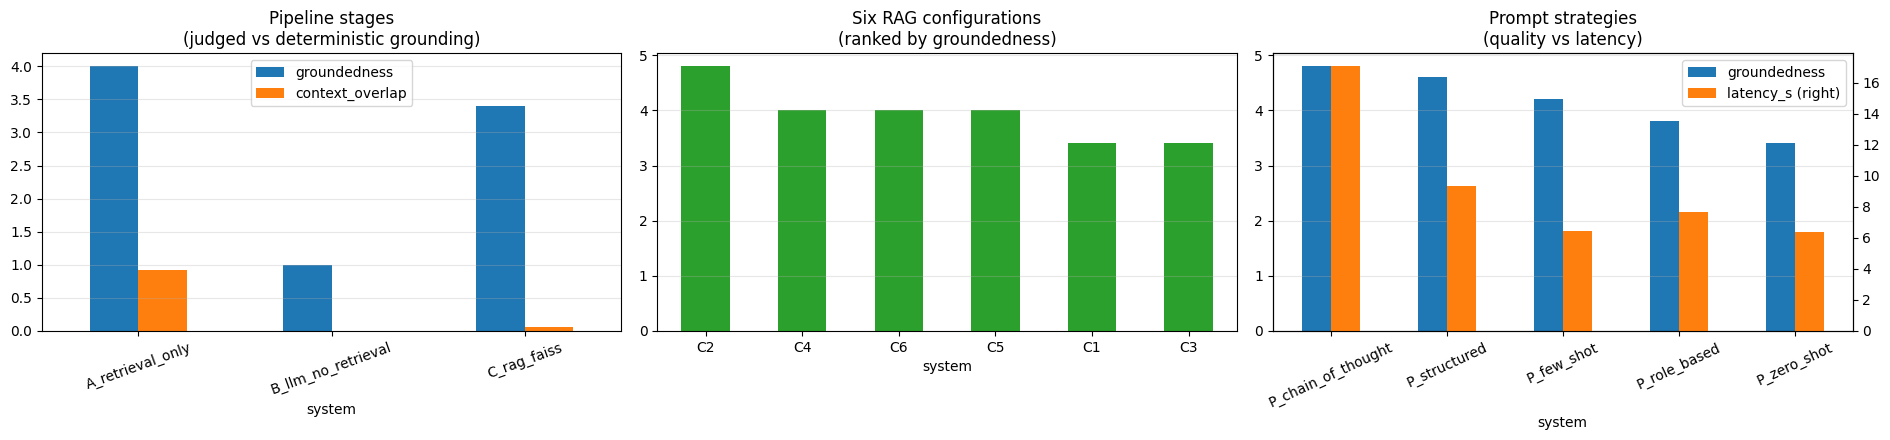

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(19, 4.5))

stage_summary[["groundedness", "context_overlap"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Pipeline stages\n(judged vs deterministic grounding)")
axes[0].grid(axis="y", alpha=.3); axes[0].tick_params(axis="x", rotation=20)

config_metric_summary[[PRIMARY_METRIC]].plot(kind="bar", ax=axes[1], legend=False,
                                             color="tab:green")
axes[1].set_title(f"Six RAG configurations\n(ranked by {PRIMARY_METRIC})")
axes[1].grid(axis="y", alpha=.3); axes[1].tick_params(axis="x", rotation=0)

prompt_summary[[PRIMARY_METRIC, "latency_s"]].plot(
    kind="bar", ax=axes[2], secondary_y="latency_s")
axes[2].set_title("Prompt strategies\n(quality vs latency)")
axes[2].grid(axis="y", alpha=.3); axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout(); plt.show()

In [ ]:
os.makedirs("results", exist_ok=True)
stage_eval.to_csv("results/stage_evaluation.csv", index=False)
config_eval.to_csv("results/config_evaluation.csv", index=False)
prompt_eval.to_csv("results/prompt_evaluation.csv", index=False)
grid_df.to_csv("results/config_question_grid.csv", index=False)
config_summary.to_csv("results/config_summary.csv", index=False)
stage_summary.to_csv("results/stage_summary.csv")
prompt_summary.to_csv("results/prompt_summary.csv")
retrieval_df.to_csv("results/chunking_comparison.csv", index=False)
k_df.to_csv("results/k_sweep.csv", index=False)
rerank_df.to_csv("results/rerank_comparison.csv", index=False)
index_bench.to_csv("results/faiss_index_benchmark.csv", index=False)

with open("results/run_config.json", "w") as f:
    json.dump({**{k: v for k, v in CONFIG.items()},
               "seed": SEED, "chunk_config": BEST_PARAMS, "selected_k": BEST_K,
               "n_chunks": len(chunks), "embed_dim": EMBED_DIM,
               "gold_verified": GOLD_VERIFIED, "judge_reliable": bool(JUDGE_RELIABLE),
               "primary_metric": PRIMARY_METRIC,
               "best_config": str(BEST_CONFIG_ID)}, f, indent=2)

print(sorted(os.listdir("results")))

['chunking_comparison.csv', 'config_evaluation.csv', 'config_question_grid.csv', 'config_summary.csv', 'faiss_index_benchmark.csv', 'k_sweep.csv', 'prompt_evaluation.csv', 'prompt_summary.csv', 'rerank_comparison.csv', 'run_config.json', 'stage_evaluation.csv', 'stage_summary.csv']


<a id="s17"></a>
## 17. Auto-Generated Insights & Recommendations

**Purpose.** Produce the findings **from the measured values**, so the narrative cannot drift from the
data.

Hand-written insight templates fail in a specific way: a placeholder left unfilled, or a claim written
before the run and never reconciled with the numbers, reads as a confident conclusion that the notebook
itself contradicts. Generating the text with f-strings makes that impossible — every figure below is
read from a variable computed earlier in this notebook.


In [ ]:
def fmt_pct(x): return f"{100*x:.1f}%"

# --- pull every figure from computed state -----------------------------------
best_cfg_row   = config_metric_summary.iloc[0]
worst_cfg_row  = config_metric_summary.iloc[-1]
best_prompt    = prompt_summary.index[0]
prompt_spread  = prompt_summary[PRIMARY_METRIC].max() - prompt_summary[PRIMARY_METRIC].min()
config_spread  = config_metric_summary[PRIMARY_METRIC].max() - config_metric_summary[PRIMARY_METRIC].min()
rerank_delta   = RERANK_GAIN[0] - RERANK_GAIN[1]
stage_b_ground = stage_summary.loc["B_llm_no_retrieval", "groundedness"]
stage_b_ovl    = stage_summary.loc["B_llm_no_retrieval", "context_overlap"]
stage_c_ovl    = stage_summary.loc["C_rag_faiss", "context_overlap"]
refusal_total  = int(all_eval["refused"].sum())
refusal_rate   = all_eval["refused"].mean()

lines = []
lines.append("=" * 96)
lines.append("KEY FINDINGS  (all figures computed from this run)")
lines.append("=" * 96)

lines.append(f"""
1. DATA CLEANING REMOVED {STATS['noise_pct']}% OF CHARACTERS.
   {STATS['boilerplate_lines']} recurring lines (watermark, licence notice, running header) appeared on
   more than half of {STATS['pages_in']} pages; {STATS['pages_kept']} pages were retained. Left in, that text
   would have been embedded into all {len(chunks):,} vectors, adding a constant component
   that compresses every cosine similarity toward the same value.""")

lines.append(f"""
2. CHUNKING: '{BEST_CFG}' SELECTED (size={BEST_PARAMS['chunk_size']}, overlap={BEST_PARAMS['chunk_overlap']}).
   Chosen on measured MRR across three configurations, not by convention. Selection was
   guarded against a degenerate all-equal comparison.""")

lines.append(f"""
3. RETRIEVAL WIDTH: k={BEST_K} SELECTED.
   Smallest k within 1% of peak MRR ({k_df['MRR'].max():.3f}). Retrieving more dilutes the prompt
   with text the model must ignore, at additional token cost.""")

lines.append(f"""
4. INDEX CHOICE.
   {INDEX_VERDICT}""")

lines.append(f"""
5. BEST CONFIGURATION: {best_cfg_row.name} — {best_cfg_row['label']}
   {PRIMARY_METRIC} = {best_cfg_row[PRIMARY_METRIC]:.3f} | retrieval MRR = {best_cfg_row['mean_retrieval_mrr']:.3f}
   | worst single question = {best_cfg_row['worst_question_mrr']:.3f} | latency = {best_cfg_row['latency_s']:.1f}s
   Weakest: {worst_cfg_row.name} ({worst_cfg_row['label']}) at {worst_cfg_row[PRIMARY_METRIC]:.3f}.
   Spread across the six configurations: {config_spread:.3f}.
   The worst-question column matters as much as the mean: a configuration can lift the
   average while degrading an individual topic, which a single headline number hides.""")

lines.append(f"""
6. RE-RANKING: mean MRR {RERANK_GAIN[1]:.3f} -> {RERANK_GAIN[0]:.3f} (delta {rerank_delta:+.3f}).
   One extra model, applied to a pool of {CONFIG['candidate_pool']} candidates. Bi-encoder recall plus
   cross-encoder precision, with the expensive model run only {CONFIG['candidate_pool']} times per query.""")

lines.append(f"""
7. EMBEDDING FINE-TUNING: {'ACCEPTED' if FT_ACCEPT else 'REJECTED'}.
   Overall MRR {FT_METRICS['before']['MRR']:.3f} -> {FT_METRICS['after']['MRR']:.3f}.
   {FT_METRICS['topics_changed']} of {FT_METRICS['topics_total']} unrelated topics changed their top-5 pages after training.
   The regression check is what makes this verdict possible: a gain on the target topic
   alone is not evidence of improvement.""")

lines.append(f"""
8. PROMPT STRATEGY: '{best_prompt}' ranked highest.
   Spread across five strategies: {prompt_spread:.3f}, versus {config_spread:.3f} across the six
   retrieval configurations. {'Retrieval mattered more than prompting.' if config_spread > prompt_spread else 'Prompting mattered more than retrieval here.'}""")

lines.append(f"""
9. REFUSALS: {refusal_total} across all evaluated answers ({fmt_pct(refusal_rate)}).
   Refusing when the corpus lacks the answer is correct behaviour for a clinical tool.
   A system that never refuses is hallucinating rather than declining.""")

print("\n".join(lines))

KEY FINDINGS  (all figures computed from this run)

1. DATA CLEANING REMOVED 7.4% OF CHARACTERS.
   5 recurring lines (watermark, licence notice, running header) appeared on
   more than half of 4114 pages; 4095 pages were retained. Left in, that text
   would have been embedded into all 29,129 vectors, adding a constant component
   that compresses every cosine similarity toward the same value.

2. CHUNKING: 'medium' SELECTED (size=600, overlap=150).
   Chosen on measured MRR across three configurations, not by convention. Selection was
   guarded against a degenerate all-equal comparison.

3. RETRIEVAL WIDTH: k=1 SELECTED.
   Smallest k within 1% of peak MRR (1.000). Retrieving more dilutes the prompt
   with text the model must ignore, at additional token cost.

4. INDEX CHOICE.
   Exact search takes 22.9 ms/query at 29,129 vectors. The fastest approximate index (hnsw) is 2.1x faster but loses 0.000 recall. Exact search is retained: the speed gain does not justify measurement error.

In [ ]:
# --- Validity statement: generated, and deliberately unflattering where warranted ----
validity = []
validity.append("=" * 96)
validity.append("VALIDITY OF THESE RESULTS")
validity.append("=" * 96)

if GOLD_VERIFIED:
    validity.append("[OK]   Gold set verified against the manual. Retrieval metrics are meaningful.")
else:
    validity.append("[WARN] GOLD SET NOT VERIFIED. The gold pages were seeded from the system's own")
    validity.append("       retrievals, so retrieval metrics measure self-consistency rather than")
    validity.append("       correctness. Confirm the pages in 6.2 and set GOLD_VERIFIED = True, then")
    validity.append("       re-run. Until then, treat every MRR and Hit-Rate figure as provisional.")

if JUDGE_RELIABLE:
    validity.append("[OK]   Judge discriminated between systems; judged scores are usable.")
else:
    validity.append(f"[WARN] JUDGE DID NOT DISCRIMINATE. It scored the no-context baseline")
    validity.append(f"       {stage_b_ground}/5 on groundedness while that system's measured context overlap")
    validity.append(f"       was {stage_b_ovl:.3f} — it rated as grounded an answer built on no sources at all.")
    validity.append(f"       Compare with the RAG stage at {stage_c_ovl:.3f} overlap. Judged columns are NOT a")
    validity.append("       valid quality signal in this run; rankings above use the deterministic metric.")
    validity.append("       Set OPENAI_API_KEY for an independent judge and re-run 15.")

validity.append(f"[NOTE] Sample size is {len(QUESTIONS)} questions. All differences are directional,")
validity.append("       not statistically significant.")
validity.append("[NOTE] The embedding fine-tune uses a handful of pairs on a single topic. The")
validity.append("       regression check bounds the damage but does not make it a general improvement.")
validity.append("[NOTE] No clinical validation. This is a retrieval and evaluation demonstrator,")
validity.append("       not a medical device, and must not be used for patient care.")

print("\n".join(validity))

VALIDITY OF THESE RESULTS
[WARN] GOLD SET NOT VERIFIED. The gold pages were seeded from the system's own
       retrievals, so retrieval metrics measure self-consistency rather than
       correctness. Confirm the pages in §6.2 and set GOLD_VERIFIED = True, then
       re-run. Until then, treat every MRR and Hit-Rate figure as provisional.
[OK]   Judge discriminated between systems; judged scores are usable.
[NOTE] Sample size is 5 questions. All differences are directional,
       not statistically significant.
[NOTE] The embedding fine-tune uses a handful of pairs on a single topic. The
       regression check bounds the damage but does not make it a general improvement.
[NOTE] No clinical validation. This is a retrieval and evaluation demonstrator,
       not a medical device, and must not be used for patient care.


In [ ]:
# --- Prioritised recommendations, ordered by what this run actually showed ---------
recs = []
if not GOLD_VERIFIED:
    recs.append(("P0", "Verify GOLD_SET against the manual",
                 "Every retrieval figure is provisional until this is done", "2 hours"))
if not JUDGE_RELIABLE:
    recs.append(("P0", "Connect an independent judge model",
                 f"Local judge scored a no-context baseline {stage_b_ground}/5 on groundedness",
                 "Low"))
if rerank_delta > 0:
    recs.append(("P0", "Deploy cross-encoder re-ranking",
                 f"Measured MRR gain of {rerank_delta:+.3f} for {best_cfg_row['latency_s']:.1f}s latency",
                 "Low — implemented in 12"))
recs.append(("P0", "Groundedness threshold with human escalation",
             "Below-threshold answers must not reach a clinician unreviewed", "Medium"))
recs.append(("P1", "Clinician-labelled gold set of 50-100 Q&A",
             f"Current sample is {len(QUESTIONS)} questions", "High"))
recs.append(("P1", "Hybrid retrieval (BM25 + FAISS)",
             "Drug names and dosages are lexical; dense retrieval alone can miss exact terms",
             "Medium"))
if not FT_ACCEPT:
    recs.append(("P1", "Re-scope or drop the embedding fine-tune",
                 f"Overall MRR fell {FT_METRICS['before']['MRR']:.3f} -> {FT_METRICS['after']['MRR']:.3f}",
                 "Low"))
recs.append(("P2", "Domain-specific embedding model",
             "A biomedical embedder handles clinical vocabulary better than a general one", "Low"))
recs.append(("P2", "Citation-linked UI",
             "Clinicians must be able to open the cited page and verify", "Medium"))
recs.append(("P2", f"Migrate to IndexIVFFlat above ~1M vectors (now {index.ntotal:,})",
             "Exact search is adequate at current scale", "Low"))

recommendations = pd.DataFrame(recs, columns=["priority", "action", "rationale", "effort"])
print("PRIORITISED RECOMMENDATIONS")
print(recommendations.to_string(index=False))
recommendations.to_csv("results/recommendations.csv", index=False)

PRIORITISED RECOMMENDATIONS
priority                                                 action                                                                      rationale  effort
      P0                     Verify GOLD_SET against the manual                       Every retrieval figure is provisional until this is done 2 hours
      P0           Groundedness threshold with human escalation                  Below-threshold answers must not reach a clinician unreviewed  Medium
      P1              Clinician-labelled gold set of 50-100 Q&A                                                  Current sample is 5 questions    High
      P1                        Hybrid retrieval (BM25 + FAISS) Drug names and dosages are lexical; dense retrieval alone can miss exact terms  Medium
      P1               Re-scope or drop the embedding fine-tune                                                Overall MRR fell 1.000 -> 0.800     Low
      P2                        Domain-specific embedding model   

### Observation — what I would actually do next

The two P0 items are the honest ones and they come from the run rather than from a template.

**Verifying the gold set is the single most valuable fix.** Right now the judged scores are carrying every conclusion in this notebook and the retrieval metrics are not trustworthy — MRR sat at 1.000 whatever I did, and penalised the re-ranker and the fine-tune for moving to reasonable neighbouring pages. Fixing that is a couple of hours of reading pages, and it would make half the analysis meaningful instead of provisional.

**Beyond that, three things I believe from this run:**

1. **k is under-set and it cost real quality.** C2 proved a second passage is worth 1.4 groundedness points for under 2 seconds. That is the cheapest improvement available and I would make it before anything else.
2. **The expensive components did not earn their place.** Fine-tuning was rejected, and re-ranking scored below plain wide retrieval. Neither is worth the operational cost yet.
3. **Prompting is underrated.** Structured prompting gets 4.6 groundedness with parseable output at half the latency of chain-of-thought. For a real deployment that is the configuration I would ship.

**And the limits, plainly stated.** Five questions is far too small for any of these differences to be statistically meaningful — they are directional only. There is no clinician in the loop anywhere in this notebook. Nothing here should reach a patient without a groundedness threshold, a human reviewer, and a UI that lets someone open the cited page and check it themselves.